In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score, GridSearchCV,
                                    StratifiedKFold)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve)
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from scipy.stats import chi2_contingency
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [78]:
np.random.seed(42)

In [79]:
df = pd.read_csv('all_data.csv')

In [80]:
df.head()

,type,cycle,cycle_pos,n,user,info,run_id,fid,C,V
0,GS,1,1,1,1,SYNTHETIC-DEMO,SYN0001,1,-1.006153,-0.500000
1,GS,1,2,2,1,SYNTHETIC-DEMO,SYN0001,1,-0.943127,-0.499285
2,GS,1,3,3,1,SYNTHETIC-DEMO,SYN0001,1,-0.947160,-0.498570
3,GS,1,4,4,1,SYNTHETIC-DEMO,SYN0001,1,-0.928697,-0.497856
4,GS,1,5,5,1,SYNTHETIC-DEMO,SYN0001,1,-0.976483,-0.497141


# Information about the Data for the Report

In [81]:
# Values for the report
print(df['cycle_pos'].nunique())    # Number of voltage positions
print(df['cycle'].max())    # Number of cycles
print(df['run_id'].nunique())   # Total samples

1400
4
75


# Data Cleaning

## Inspecting the data

We display the first few rows, check data types, and get a summary of the DataFrame to understand its structure and identify potential issues.

In [82]:
display(df.info())
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 420000 entries, 0 to 419999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   type       420000 non-null  str    
 1   cycle      420000 non-null  int64  
 2   cycle_pos  420000 non-null  int64  
 3   n          420000 non-null  int64  
 4   user       420000 non-null  int64  
 5   info       420000 non-null  str    
 6   run_id     420000 non-null  str    
 7   fid        420000 non-null  int64  
 8   C          420000 non-null  float64
 9   V          420000 non-null  float64
dtypes: float64(2), int64(5), str(3)
memory usage: 32.0 MB


None

,cycle,cycle_pos,n,user,fid,C,V
count,420000.000000,420000.000000,420000.000000,420000.0,420000.000000,420000.000000,4.200000e+05
mean,2.500000,700.500000,2800.500000,1.0,38.000000,2.130852,1.028595e-17
std,1.118035,404.145566,1616.582652,0.0,21.648736,5.395838,2.888817e-01
min,1.000000,1.000000,1.000000,1.0,1.000000,-10.713154,-5.000000e-01
25%,1.750000,350.750000,1400.750000,1.0,19.000000,-0.944215,-2.500000e-01
50%,2.500000,700.500000,2800.500000,1.0,38.000000,0.504684,0.000000e+00
75%,3.250000,1050.250000,4200.250000,1.0,57.000000,4.212758,2.500000e-01
max,4.000000,1400.000000,5600.000000,1.0,75.000000,23.552258,5.000000e-01


## Handling missing values

We identify and address any missing values in the DataFrame. This might involve dropping rows or columns with missing values, or filling them with appropriate values (e.g., mean, median, mode).


In [83]:
missing_values_count = df.isnull().sum()
print(missing_values_count)

type         0
cycle        0
cycle_pos    0
n            0
user         0
info         0
run_id       0
fid          0
C            0
V            0
dtype: int64


## Handling duplicate data

We identify and remove duplicate rows from the DataFrame.


In [84]:
duplicate_rows_count = df.duplicated().sum()
print(f"Number of duplicate rows before dropping: {duplicate_rows_count}")

Number of duplicate rows before dropping: 0


## Correcting data types

We convert columns to appropriate data types if they are incorrectly inferred during loading.


In [85]:
df['user'] = df['user'].astype('category')
df['type'] = df['type'].astype('category')
df['info'] = df['info'].astype('category')
df['run_id'] = df['run_id'].astype('category')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420000 entries, 0 to 419999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   type       420000 non-null  category
 1   cycle      420000 non-null  int64   
 2   cycle_pos  420000 non-null  int64   
 3   n          420000 non-null  int64   
 4   user       420000 non-null  category
 5   info       420000 non-null  category
 6   run_id     420000 non-null  category
 7   fid        420000 non-null  int64   
 8   C          420000 non-null  float64 
 9   V          420000 non-null  float64 
dtypes: category(4), float64(2), int64(4)
memory usage: 20.8 MB


## Handling inconsistencies and errors

We identify and correct any inconsistencies or errors in the data, such as incorrect entries or formatting issues.


In [86]:
print("Unique values in 'type' column:")
print(df['type'].unique())
print("\nUnique values in 'user' column:")
print(df['user'].unique())
print("\nUnique values in 'info' column:")
print(df['info'].unique())
print("\nUnique values in 'run_id' column:")
print(df['run_id'].unique())

Unique values in 'type' column:
['GS', 'CF', 'FT']
Categories (3, str): ['CF', 'FT', 'GS']

Unique values in 'user' column:
[1]
Categories (1, int64): [1]

Unique values in 'info' column:
['SYNTHETIC-DEMO']
Categories (1, str): ['SYNTHETIC-DEMO']

Unique values in 'run_id' column:
['SYN0001', 'SYN0002', 'SYN0003', 'SYN0004', 'SYN0005', ..., 'SYN0071', 'SYN0072', 'SYN0073', 'SYN0074', 'SYN0075']
Length: 75
Categories (75, str): ['SYN0001', 'SYN0002', 'SYN0003', 'SYN0004', ..., 'SYN0072', 'SYN0073', 'SYN0074', 'SYN0075']


In [87]:
df['user'] = df['user'].astype(str)
print("\nUnique values in 'user' column after standardization:")
print(df['user'].unique())


Unique values in 'user' column after standardization:
<StringArray>
['1']
Length: 1, dtype: str


In [88]:
df_no_5 = df[df.cycle <= 4]

In [89]:
df_no_5.shape

(420000, 10)

In [90]:
df_no_5_with_FT = df_no_5.copy()

In [91]:
df_no_5 = df_no_5[df_no_5.type != 'FT']

In [92]:
df_no_5.shape

(308000, 10)

In [93]:
df_no_5_with_FT.shape

(420000, 10)

In [94]:
print("Unique values in 'type' column:")
print(df_no_5['type'].unique())

Unique values in 'type' column:
['GS', 'CF']
Categories (3, str): ['CF', 'FT', 'GS']


## Verifying the cleaning

After performing the cleaning steps, we reinspect the data to ensure that the issues have been addressed and that the data is in a suitable format for analysis.


In [95]:
display(df_no_5.head())
display(df_no_5.info())
display(df_no_5.describe())

,type,cycle,cycle_pos,n,user,info,run_id,fid,C,V
0,GS,1,1,1,1,SYNTHETIC-DEMO,SYN0001,1,-1.006153,-0.500000
1,GS,1,2,2,1,SYNTHETIC-DEMO,SYN0001,1,-0.943127,-0.499285
2,GS,1,3,3,1,SYNTHETIC-DEMO,SYN0001,1,-0.947160,-0.498570
3,GS,1,4,4,1,SYNTHETIC-DEMO,SYN0001,1,-0.928697,-0.497856
4,GS,1,5,5,1,SYNTHETIC-DEMO,SYN0001,1,-0.976483,-0.497141


<class 'pandas.DataFrame'>
RangeIndex: 308000 entries, 0 to 307999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   type       308000 non-null  category
 1   cycle      308000 non-null  int64   
 2   cycle_pos  308000 non-null  int64   
 3   n          308000 non-null  int64   
 4   user       308000 non-null  str     
 5   info       308000 non-null  category
 6   run_id     308000 non-null  category
 7   fid        308000 non-null  int64   
 8   C          308000 non-null  float64 
 9   V          308000 non-null  float64 
dtypes: category(3), float64(2), int64(4), str(1)
memory usage: 17.3 MB


None

,cycle,cycle_pos,n,fid,C,V
count,308000.000000,308000.000000,308000.000000,308000.000000,308000.000000,3.080000e+05
mean,2.500000,700.500000,2800.500000,28.000000,2.063964,1.181162e-17
std,1.118036,404.145741,1616.583352,15.874534,5.454833,2.888819e-01
min,1.000000,1.000000,1.000000,1.000000,-10.713154,-5.000000e-01
25%,1.750000,350.750000,1400.750000,14.000000,-0.984417,-2.500000e-01
50%,2.500000,700.500000,2800.500000,28.000000,0.506790,0.000000e+00
75%,3.250000,1050.250000,4200.250000,42.000000,4.016520,2.500000e-01
max,4.000000,1400.000000,5600.000000,55.000000,23.486356,5.000000e-01


# Visuals

We now identify correlations.

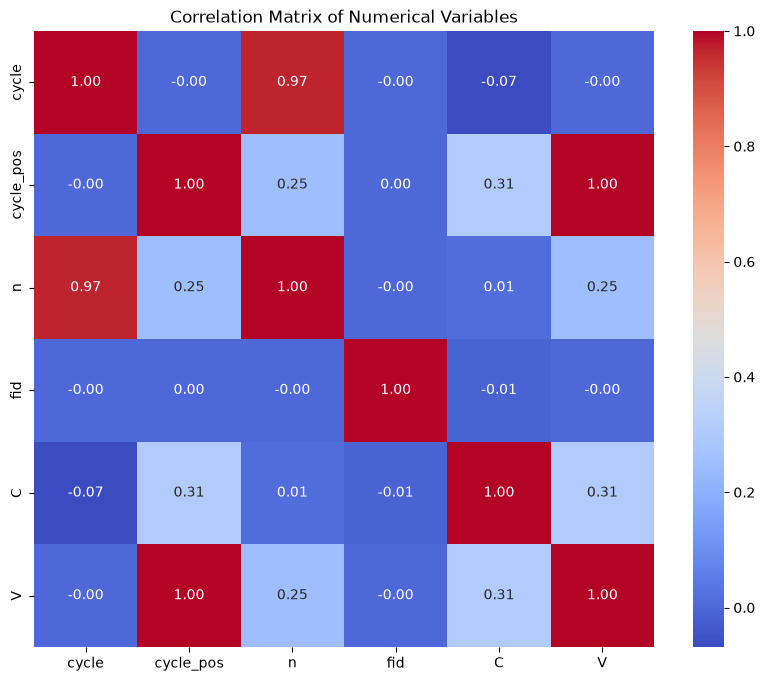

In [96]:
# Select numerical columns for correlation analysis
numerical_df = df_no_5.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

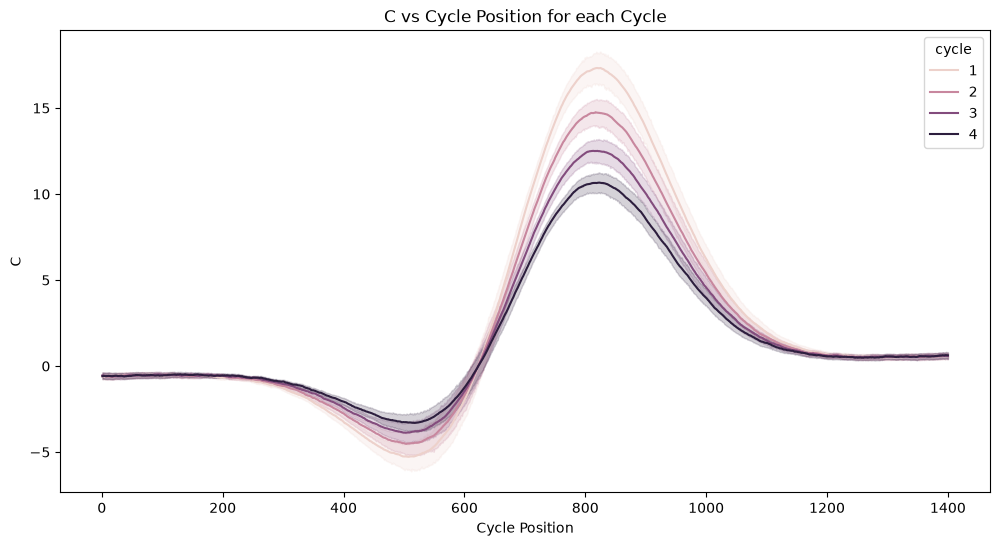

In [97]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_no_5, x='cycle_pos', y='C', hue='cycle')
plt.title('C vs Cycle Position for each Cycle')
plt.xlabel('Cycle Position')
plt.ylabel('C')
plt.show()

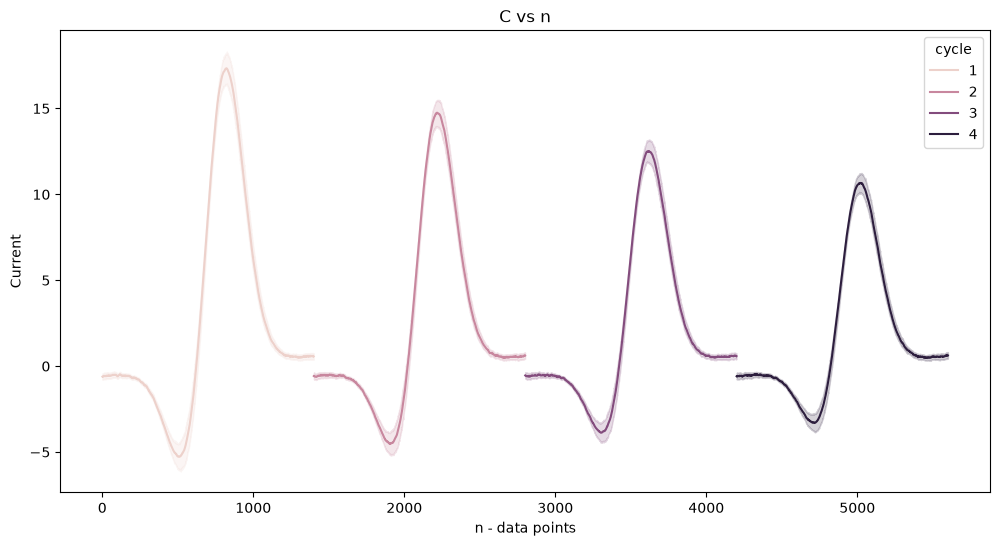

In [98]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_no_5, x='n', y='C', hue='cycle')
plt.title('C vs n')
plt.xlabel('n - data points')
plt.ylabel('Current')
plt.show()

# Prepare Data for PCA

In [99]:
# Create feature matrix for ALL types (GS, CF, FT)
pivot_data_all = df_no_5_with_FT.groupby(['run_id', 'cycle_pos'])['C'].mean().unstack(fill_value=np.nan)
labels_all = df_no_5_with_FT.groupby('run_id')['type'].first()

X_all_full = pivot_data_all.values
y_all_full = labels_all.values
run_ids_all = pivot_data_all.index.values

print(f"Loaded complete dataset")
print(f"  Total samples: {len(X_all_full)}")
print(f"  GS: {np.sum(y_all_full == 'GS')}")
print(f"  CF: {np.sum(y_all_full == 'CF')}")
print(f"  FT: {np.sum(y_all_full == 'FT')}")
print(f"  Features: {X_all_full.shape[1]}")

Loaded complete dataset
  Total samples: 75
  GS: 40
  CF: 15
  FT: 20
  Features: 1400


In [100]:
# Preprocess
imputer = SimpleImputer(strategy='mean')
X_all_full = imputer.fit_transform(X_all_full)

scaler_full = StandardScaler()
X_all_scaled = scaler_full.fit_transform(X_all_full)

In [101]:
# First, filter to GS+CF for outlier detection
gs_cf_mask = (y_all_full == 'GS') | (y_all_full == 'CF')
X_gs_cf = X_all_scaled[gs_cf_mask]
y_gs_cf = y_all_full[gs_cf_mask]
run_ids_gs_cf = run_ids_all[gs_cf_mask]

In [102]:
# PCA for outlier detection
pca_check = PCA(n_components=2)
X_pca_check = pca_check.fit_transform(X_gs_cf)

In [103]:
# Find outlier using z-score
gs_mask = y_gs_cf == 'GS'
gs_mean_pc1 = X_pca_check[gs_mask, 0].mean()
gs_std_pc1 = X_pca_check[gs_mask, 0].std()
gs_mean_pc2 = X_pca_check[gs_mask, 1].mean()
gs_std_pc2 = X_pca_check[gs_mask, 1].std()

z1 = (X_pca_check[gs_mask, 0] - gs_mean_pc1) / gs_std_pc1
z2 = (X_pca_check[gs_mask, 1] - gs_mean_pc2) / gs_std_pc2
z_combined = np.sqrt(z1**2 + z2**2)

outlier_mask_gs = z_combined > 2.5
outlier_idx_local = np.where(gs_mask)[0][outlier_mask_gs]
outlier_run_id = run_ids_gs_cf[outlier_idx_local[0]] if len(outlier_idx_local) > 0 else None

print(f"Outlier identified: {outlier_run_id}")
print(f"Location: PC1={X_pca_check[outlier_idx_local[0], 0]:.2f}, PC2={X_pca_check[outlier_idx_local[0], 1]:.2f}")

Outlier identified: SYN0008
Location: PC1=34.51, PC2=25.84


In [104]:
# Remove outlier for clean PCA
keep_mask_gs_cf = np.ones(len(X_gs_cf), dtype=bool)
keep_mask_gs_cf[outlier_idx_local] = False

X_gs_cf_clean = X_gs_cf[keep_mask_gs_cf]
y_gs_cf_clean = y_gs_cf[keep_mask_gs_cf]
run_ids_gs_cf_clean = run_ids_gs_cf[keep_mask_gs_cf]

# PCA

In [105]:
pca_outlier = PCA(n_components=2)
X_pca_outlier = pca_outlier.fit_transform(X_gs_cf)

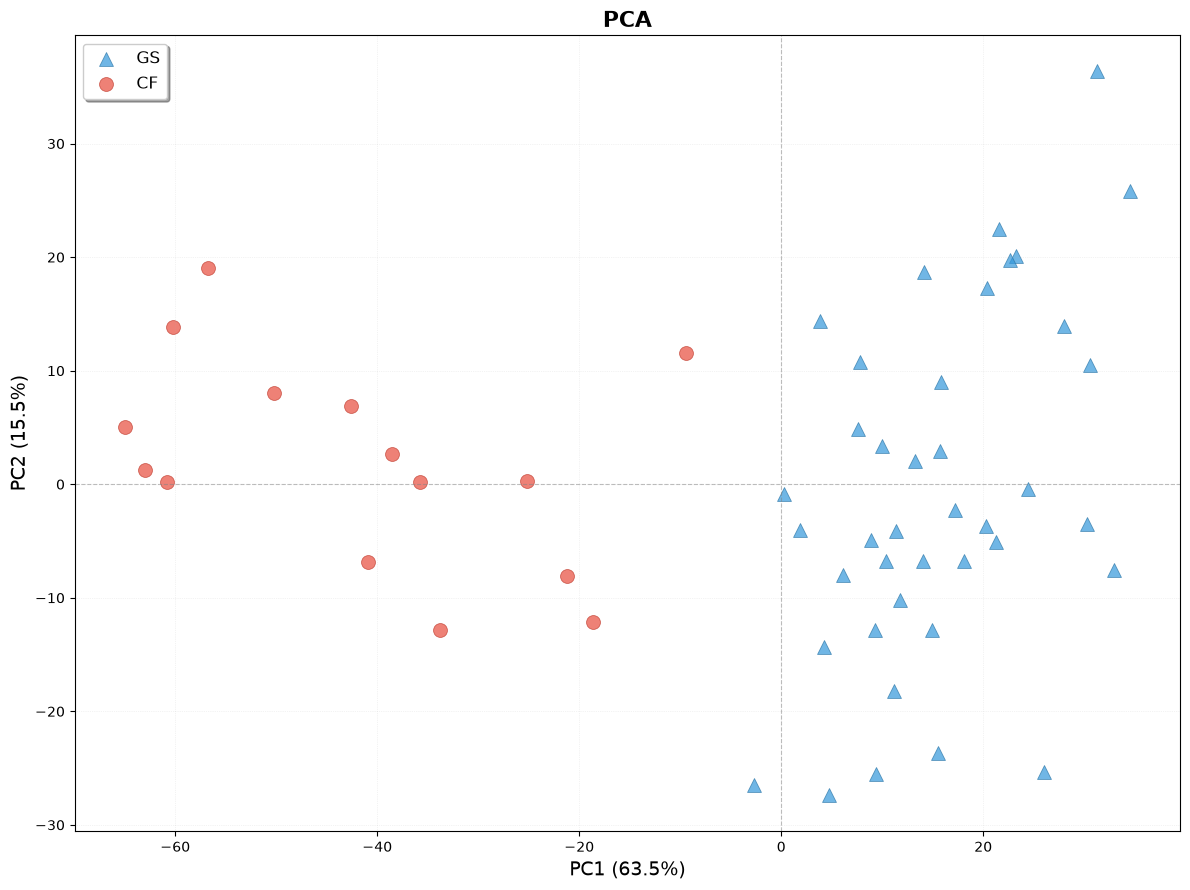

In [106]:
fig, ax = plt.subplots(figsize=(12, 9))

gs_outlier = y_gs_cf == 'GS'
cf_outlier = y_gs_cf == 'CF'

ax.scatter(X_pca_outlier[gs_outlier, 0], X_pca_outlier[gs_outlier, 1],
           c='#3498db', marker='^', s=100, alpha=0.7,
           label='GS', edgecolors='#2874a6', linewidth=0.6)
ax.scatter(X_pca_outlier[cf_outlier, 0], X_pca_outlier[cf_outlier, 1],
           c='#e74c3c', marker='o', s=100, alpha=0.7,
           label='CF', edgecolors='#c0392b', linewidth=0.6)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel(f'PC1 ({pca_outlier.explained_variance_ratio_[0]*100:.1f}%)', fontsize=14)
ax.set_ylabel(f'PC2 ({pca_outlier.explained_variance_ratio_[1]*100:.1f}%)', fontsize=14)
ax.set_title('PCA', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

plt.tight_layout()

plt.show()

In [107]:
pca_clean = PCA(n_components=2)
X_pca_clean = pca_clean.fit_transform(X_gs_cf_clean)

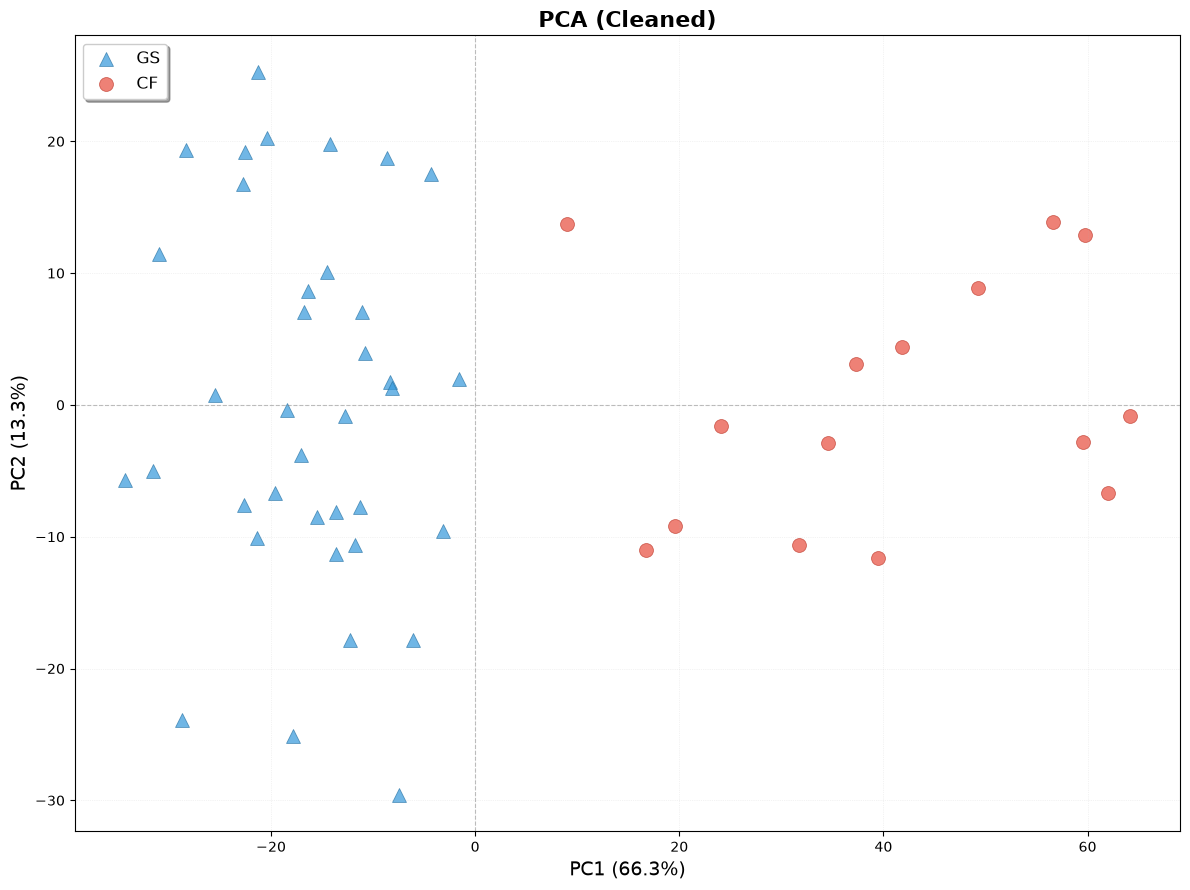

In [108]:
fig, ax = plt.subplots(figsize=(12, 9))

gs_clean = y_gs_cf_clean == 'GS'
cf_clean = y_gs_cf_clean == 'CF'

ax.scatter(X_pca_clean[gs_clean, 0], X_pca_clean[gs_clean, 1],
           c='#3498db', marker='^', s=100, alpha=0.7,
           label='GS', edgecolors='#2874a6', linewidth=0.6)
ax.scatter(X_pca_clean[cf_clean, 0], X_pca_clean[cf_clean, 1],
           c='#e74c3c', marker='o', s=100, alpha=0.7,
           label='CF', edgecolors='#c0392b', linewidth=0.6)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel(f'PC1 ({pca_clean.explained_variance_ratio_[0]*100:.1f}%)', fontsize=14)
ax.set_ylabel(f'PC2 ({pca_clean.explained_variance_ratio_[1]*100:.1f}%)', fontsize=14)
ax.set_title('PCA (Cleaned)', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

plt.tight_layout()

plt.show()

# Prepare Data for Classification

In [109]:
# Remove outlier from FULL dataset (not just PCA)
outlier_mask_full = run_ids_all == outlier_run_id
X_clean_full = X_all_scaled[~outlier_mask_full]
y_clean_full = y_all_full[~outlier_mask_full]
run_ids_clean_full = run_ids_all[~outlier_mask_full]

print(f"\nFull cleaned dataset prepared:")
print(f"Total samples: {len(X_clean_full)} (removed 1 outlier)")
print(f"Features: {X_clean_full.shape[1]} (all 1400 electrochemical features)")
print(f"GS: {np.sum(y_clean_full == 'GS')}")
print(f"CF: {np.sum(y_clean_full == 'CF')}")
print(f"FT: {np.sum(y_clean_full == 'FT')}")


Full cleaned dataset prepared:
Total samples: 74 (removed 1 outlier)
Features: 1400 (all 1400 electrochemical features)
GS: 39
CF: 15
FT: 20


In [110]:
# For binary classification (GS vs CF)
binary_mask = (y_clean_full == 'GS') | (y_clean_full == 'CF')
X_binary = X_clean_full[binary_mask]
y_binary = y_clean_full[binary_mask]
run_ids_binary = run_ids_clean_full[binary_mask]

# Convert to numeric (0=CF, 1=GS)
y_binary_numeric = (y_binary == 'GS').astype(int)

print(f"\nBinary classification data (GS vs CF):")
print(f"Total: {len(X_binary)}")
print(f"GS: {np.sum(y_binary_numeric == 1)}")
print(f"CF: {np.sum(y_binary_numeric == 0)}")


Binary classification data (GS vs CF):
Total: 54
GS: 39
CF: 15


In [111]:
# FT DATA: Field test samples to be classified
ft_mask = y_clean_full == 'FT'
X_ft = X_clean_full[ft_mask]
y_ft = y_clean_full[ft_mask]
run_ids_ft = run_ids_clean_full[ft_mask]

print(f"FT samples (to be classified):")
print(f"Total: {len(X_ft)}")

FT samples (to be classified):
Total: 20


In [112]:
class SIMCAClassifier:
    """
    SIMCA: Soft Independent Modeling of Class Analogy

    Each class is modeled independently using PCA.
    Classification is based on distance to each class model.
    Provides probability of membership and allows uncertain classifications.
    """

    def __init__(self, n_components=5, alpha=0.05):
        """
        Parameters:
        -----------
        n_components : int or dict
            Number of PCA components for each class
        alpha : float
            Significance level for outlier detection (default: 0.05)
        """
        self.n_components = n_components
        self.alpha = alpha
        self.models = {}
        self.classes_ = None

    def fit(self, X, y):
        """Build separate PCA model for each class"""
        self.classes_ = np.unique(y)

        for cls in self.classes_:
            X_cls = X[y == cls]

            # Determine number of components for this class
            if isinstance(self.n_components, dict):
                n_comp = self.n_components.get(cls, 5)
            else:
                n_comp = min(self.n_components, X_cls.shape[0] - 1, X_cls.shape[1])

            # Build PCA model
            pca = PCA(n_components=n_comp)
            X_proj = pca.fit_transform(X_cls)

            # Calculate statistics
            mean = X_cls.mean(axis=0)

            # Reconstruct and compute residuals
            X_recon = pca.inverse_transform(X_proj)
            residuals = X_cls - X_recon
            residual_var = np.var(residuals, axis=0).sum()

            # Store model
            self.models[cls] = {
                'pca': pca,
                'mean': mean,
                'residual_var': residual_var,
                'n_samples': len(X_cls),
                'n_features': X_cls.shape[1],
                'n_components': n_comp
            }

        return self

    def _compute_distance(self, X, cls):
        """Compute normalized distance to class model"""
        model = self.models[cls]
        pca = model['pca']

        # Project and reconstruct
        X_proj = pca.transform(X)
        X_recon = pca.inverse_transform(X_proj)

        # Residuals
        residuals = X - X_recon
        residual_norm = np.sum(residuals**2, axis=1)

        # Normalised distance (Q-statistic)
        Q = residual_norm / (model['residual_var'] + 1e-10)

        return Q

    def predict_proba(self, X):
        """
        Predict class membership probabilities

        Returns probabilities based on inverse distance to each class model
        """
        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        # Compute distances to each class
        distances = np.zeros((n_samples, n_classes))
        for i, cls in enumerate(self.classes_):
            distances[:, i] = self._compute_distance(X, cls)

        # Converte distances to probabilities (inverse distance, normalised)
        # We added small constant to avoid division by zero
        inv_distances = 1.0 / (distances + 1e-6)
        proba = inv_distances / inv_distances.sum(axis=1, keepdims=True)

        return proba

    def predict(self, X):
        """Predict class labels based on minimum distance"""
        proba = self.predict_proba(X)
        class_indices = np.argmax(proba, axis=1)
        return np.array([self.classes_[i] for i in class_indices])

    def decision_function(self, X):
        """Return distances to each class (for compatibility)"""
        n_samples = X.shape[0]
        distances = np.zeros((n_samples, len(self.classes_)))
        for i, cls in enumerate(self.classes_):
            distances[:, i] = self._compute_distance(X, cls)
        return -distances  # Negative so higher is better

In [113]:
N_SPLITS = 10  # Number of different random splits
TEST_SIZE = 0.25

# Initialize models
models_config = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(50, 20), max_iter=1000, random_state=42),
    'SIMCA': SIMCAClassifier(n_components=10, alpha=0.05)
}

# Store results across splits
results_across_splits = {name: {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'specificity': [],
    'f1_score': [],
    'sensitivity': []  # Same as recall
} for name in models_config.keys()}

Ran 10 train-test splits. Used ful feature space (1400).

In [114]:
for split_num in range(N_SPLITS):
    # Random split with different random state each time
    X_train, X_test, y_train, y_test = train_test_split(
        X_binary, y_binary_numeric,
        test_size=TEST_SIZE,
        random_state=42 + split_num,  # Different seed each time
        stratify=y_binary_numeric
    )

    for name, model_template in models_config.items():
        # Create fresh model instance
        if name == 'SIMCA':
            model = SIMCAClassifier(n_components=10, alpha=0.05)
        elif name == 'Logistic Regression':
            model = LogisticRegression(random_state=42, max_iter=1000)
        elif name == 'SVM (Linear)':
            model = SVC(kernel='linear', probability=True, random_state=42)
        elif name == 'SVM (RBF)':
            model = SVC(kernel='rbf', probability=True, random_state=42)
        elif name == 'Random Forest':
            model = RandomForestClassifier(n_estimators=100, random_state=42)
        elif name == 'Neural Network':
            model = MLPClassifier(hidden_layer_sizes=(50, 20), max_iter=1000, random_state=42)

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Metrics
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred)  # Sensitivity / TPR
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
        f1 = f1_score(y_test, y_pred, zero_division=0)

        results_across_splits[name]['accuracy'].append(accuracy)
        results_across_splits[name]['precision'].append(precision)
        results_across_splits[name]['recall'].append(recall)
        results_across_splits[name]['sensitivity'].append(recall)  # Same as recall
        results_across_splits[name]['specificity'].append(specificity)
        results_across_splits[name]['f1_score'].append(f1)

    if (split_num + 1) % 5 == 0:
        print(f"Completed {split_num + 1}/{N_SPLITS} splits")

Completed 5/10 splits
Completed 10/10 splits


Completed 10 splits.

# Classifications

In [115]:
averaged_results = {}
for name in models_config.keys():
    avg_acc = np.mean(results_across_splits[name]['accuracy'])
    std_acc = np.std(results_across_splits[name]['accuracy'])

    avg_sens = np.mean(results_across_splits[name]['sensitivity'])
    std_sens = np.std(results_across_splits[name]['sensitivity'])

    avg_spec = np.mean(results_across_splits[name]['specificity'])
    std_spec = np.std(results_across_splits[name]['specificity'])

    avg_f1 = np.mean(results_across_splits[name]['f1_score'])
    std_f1 = np.std(results_across_splits[name]['f1_score'])

    averaged_results[name] = {
        'accuracy_mean': avg_acc,
        'accuracy_std': std_acc,
        'sensitivity_mean': avg_sens,
        'sensitivity_std': std_sens,
        'specificity_mean': avg_spec,
        'specificity_std': std_spec,
        'f1_mean': avg_f1,
        'f1_std': std_f1
    }

    print(f"{name:<20} {avg_acc:.3f}±{std_acc:.3f}    {avg_sens:.3f}±{std_sens:.3f}    "
          f"{avg_spec:.3f}±{std_spec:.3f}    {avg_f1:.3f}±{std_f1:.3f}")

Logistic Regression  0.993±0.021    1.000±0.000    0.975±0.075    0.995±0.014
SVM (Linear)         0.971±0.035    1.000±0.000    0.900±0.122    0.981±0.023
SVM (RBF)            0.971±0.035    1.000±0.000    0.900±0.122    0.981±0.023
Random Forest        0.993±0.021    1.000±0.000    0.975±0.075    0.995±0.014
Neural Network       1.000±0.000    1.000±0.000    1.000±0.000    1.000±0.000
SIMCA                0.714±0.000    1.000±0.000    0.000±0.000    0.833±0.000


In [116]:
# Train models on full data
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_binary, y_binary_numeric,
    test_size=0.25,
    random_state=42,
    stratify=y_binary_numeric
)

In [117]:
final_models = {}

# Train all 6 models
lr_final = LogisticRegression(random_state=42, max_iter=1000)
lr_final.fit(X_train_final, y_train_final)
final_models['Logistic Regression'] = lr_final

svm_linear_final = SVC(kernel='linear', probability=True, random_state=42)
svm_linear_final.fit(X_train_final, y_train_final)
final_models['SVM (Linear)'] = svm_linear_final

svm_rbf_final = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf_final.fit(X_train_final, y_train_final)
final_models['SVM (RBF)'] = svm_rbf_final

rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train_final, y_train_final)
final_models['Random Forest'] = rf_final

mlp_final = MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=500, random_state=42, early_stopping=True)
mlp_final.fit(X_train_final, y_train_final)
final_models['Neural Network'] = mlp_final

simca_final = SIMCAClassifier(n_components=10, alpha=0.05)
simca_final.fit(X_train_final, y_train_final)
final_models['SIMCA'] = simca_final



In [118]:
# Get test predictions (CF & GS only)
test_predictions = {}
for name, model in final_models.items():
    test_predictions[name] = model.predict(X_test_final)

In [119]:
ft_predictions = {}
ft_probabilities = {}

for name, model in final_models.items():
    ft_predictions[name] = model.predict(X_ft)

    # Get probabilities if available
    if hasattr(model, 'predict_proba'):
        ft_probabilities[name] = model.predict_proba(X_ft)
    elif hasattr(model, 'decision_function'):
        # For models without predict_proba, use decision function
        decision = model.decision_function(X_ft)
        if decision.ndim == 1:
            # Binary classification decision function
            proba = 1 / (1 + np.exp(-decision))
            ft_probabilities[name] = np.column_stack([1 - proba, proba])
        else:
            ft_probabilities[name] = decision

Predicted 20 FT samples.

In [120]:
print(f"{'Model':<20} {'Predicted CF':<15} {'Predicted GS':<15}")
for name in final_models.keys():
    n_cf = np.sum(ft_predictions[name] == 0)
    n_gs = np.sum(ft_predictions[name] == 1)
    print(f"{name:<20} {n_cf:<15} {n_gs:<15}")

Model                Predicted CF    Predicted GS   
Logistic Regression  10              10             
SVM (Linear)         10              10             
SVM (RBF)            10              10             
Random Forest        10              10             
Neural Network       10              10             
SIMCA                0               20             


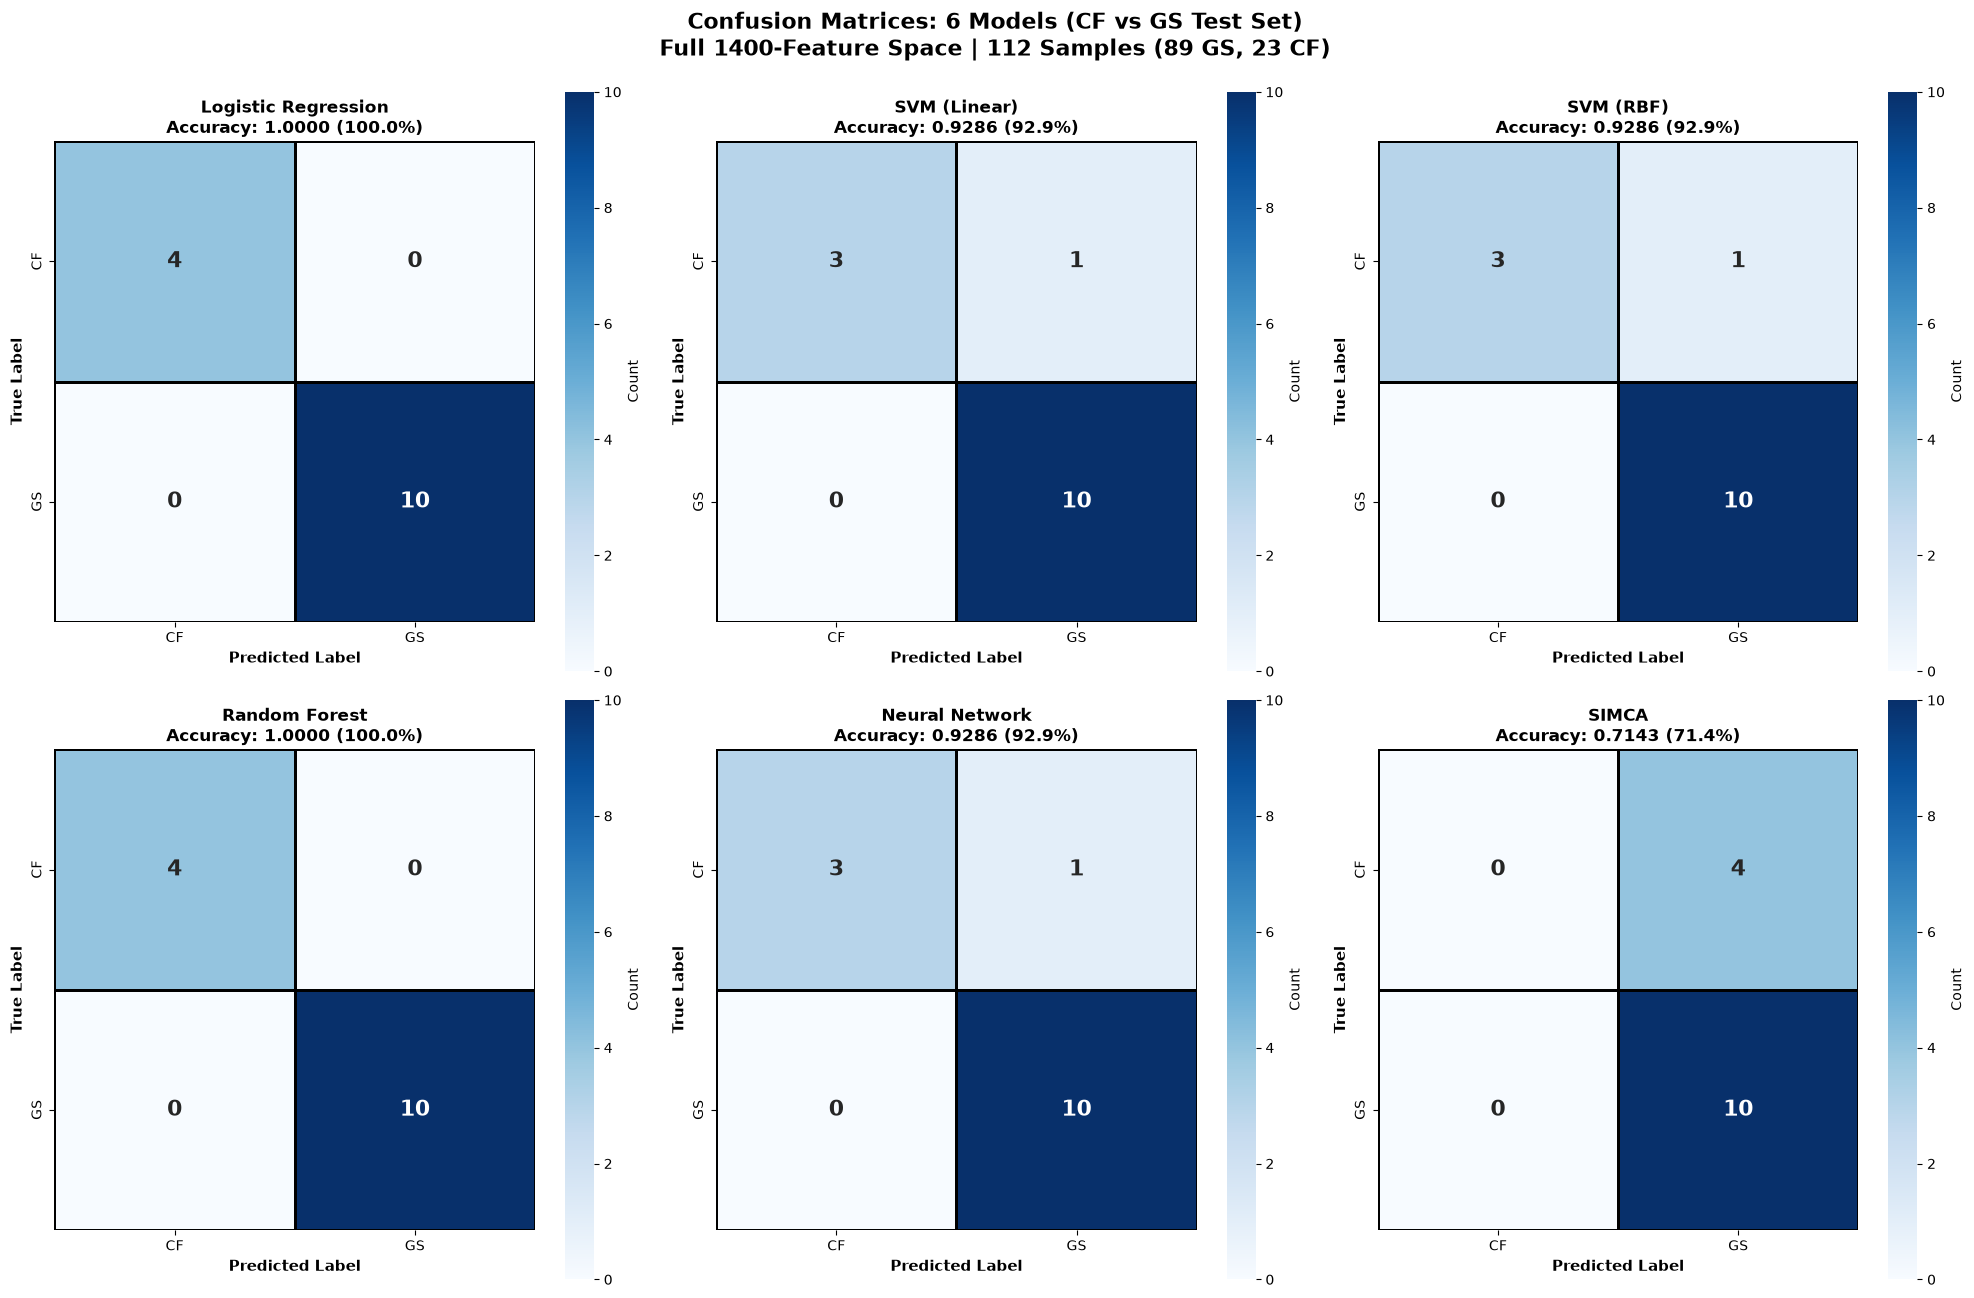

In [121]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.ravel()

for idx, (name, predictions) in enumerate(test_predictions.items()):
    ax = axes[idx]

    cm = confusion_matrix(y_test_final, predictions)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['CF', 'GS'], yticklabels=['CF', 'GS'],
               ax=ax, cbar=True, square=True,
               linewidths=2, linecolor='black',
               annot_kws={'size': 16, 'weight': 'bold'},
               cbar_kws={'label': 'Count'})

    accuracy = accuracy_score(y_test_final, predictions)

    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.set_title(f'{name}\nAccuracy: {accuracy:.4f} ({accuracy*100:.1f}%)',
                fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices: 6 Models (CF vs GS Test Set)\nFull 1400-Feature Space | 112 Samples (89 GS, 23 CF)',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [122]:
metrics_data = []

for name, predictions in test_predictions.items():
    cm = confusion_matrix(y_test_final, predictions)
    accuracy = accuracy_score(y_test_final, predictions)
    precision = precision_score(y_test_final, predictions, zero_division=0)
    recall = recall_score(y_test_final, predictions)
    f1 = f1_score(y_test_final, predictions)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    metrics_data.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1_Score': f1
    })

metrics_df = pd.DataFrame(metrics_data)

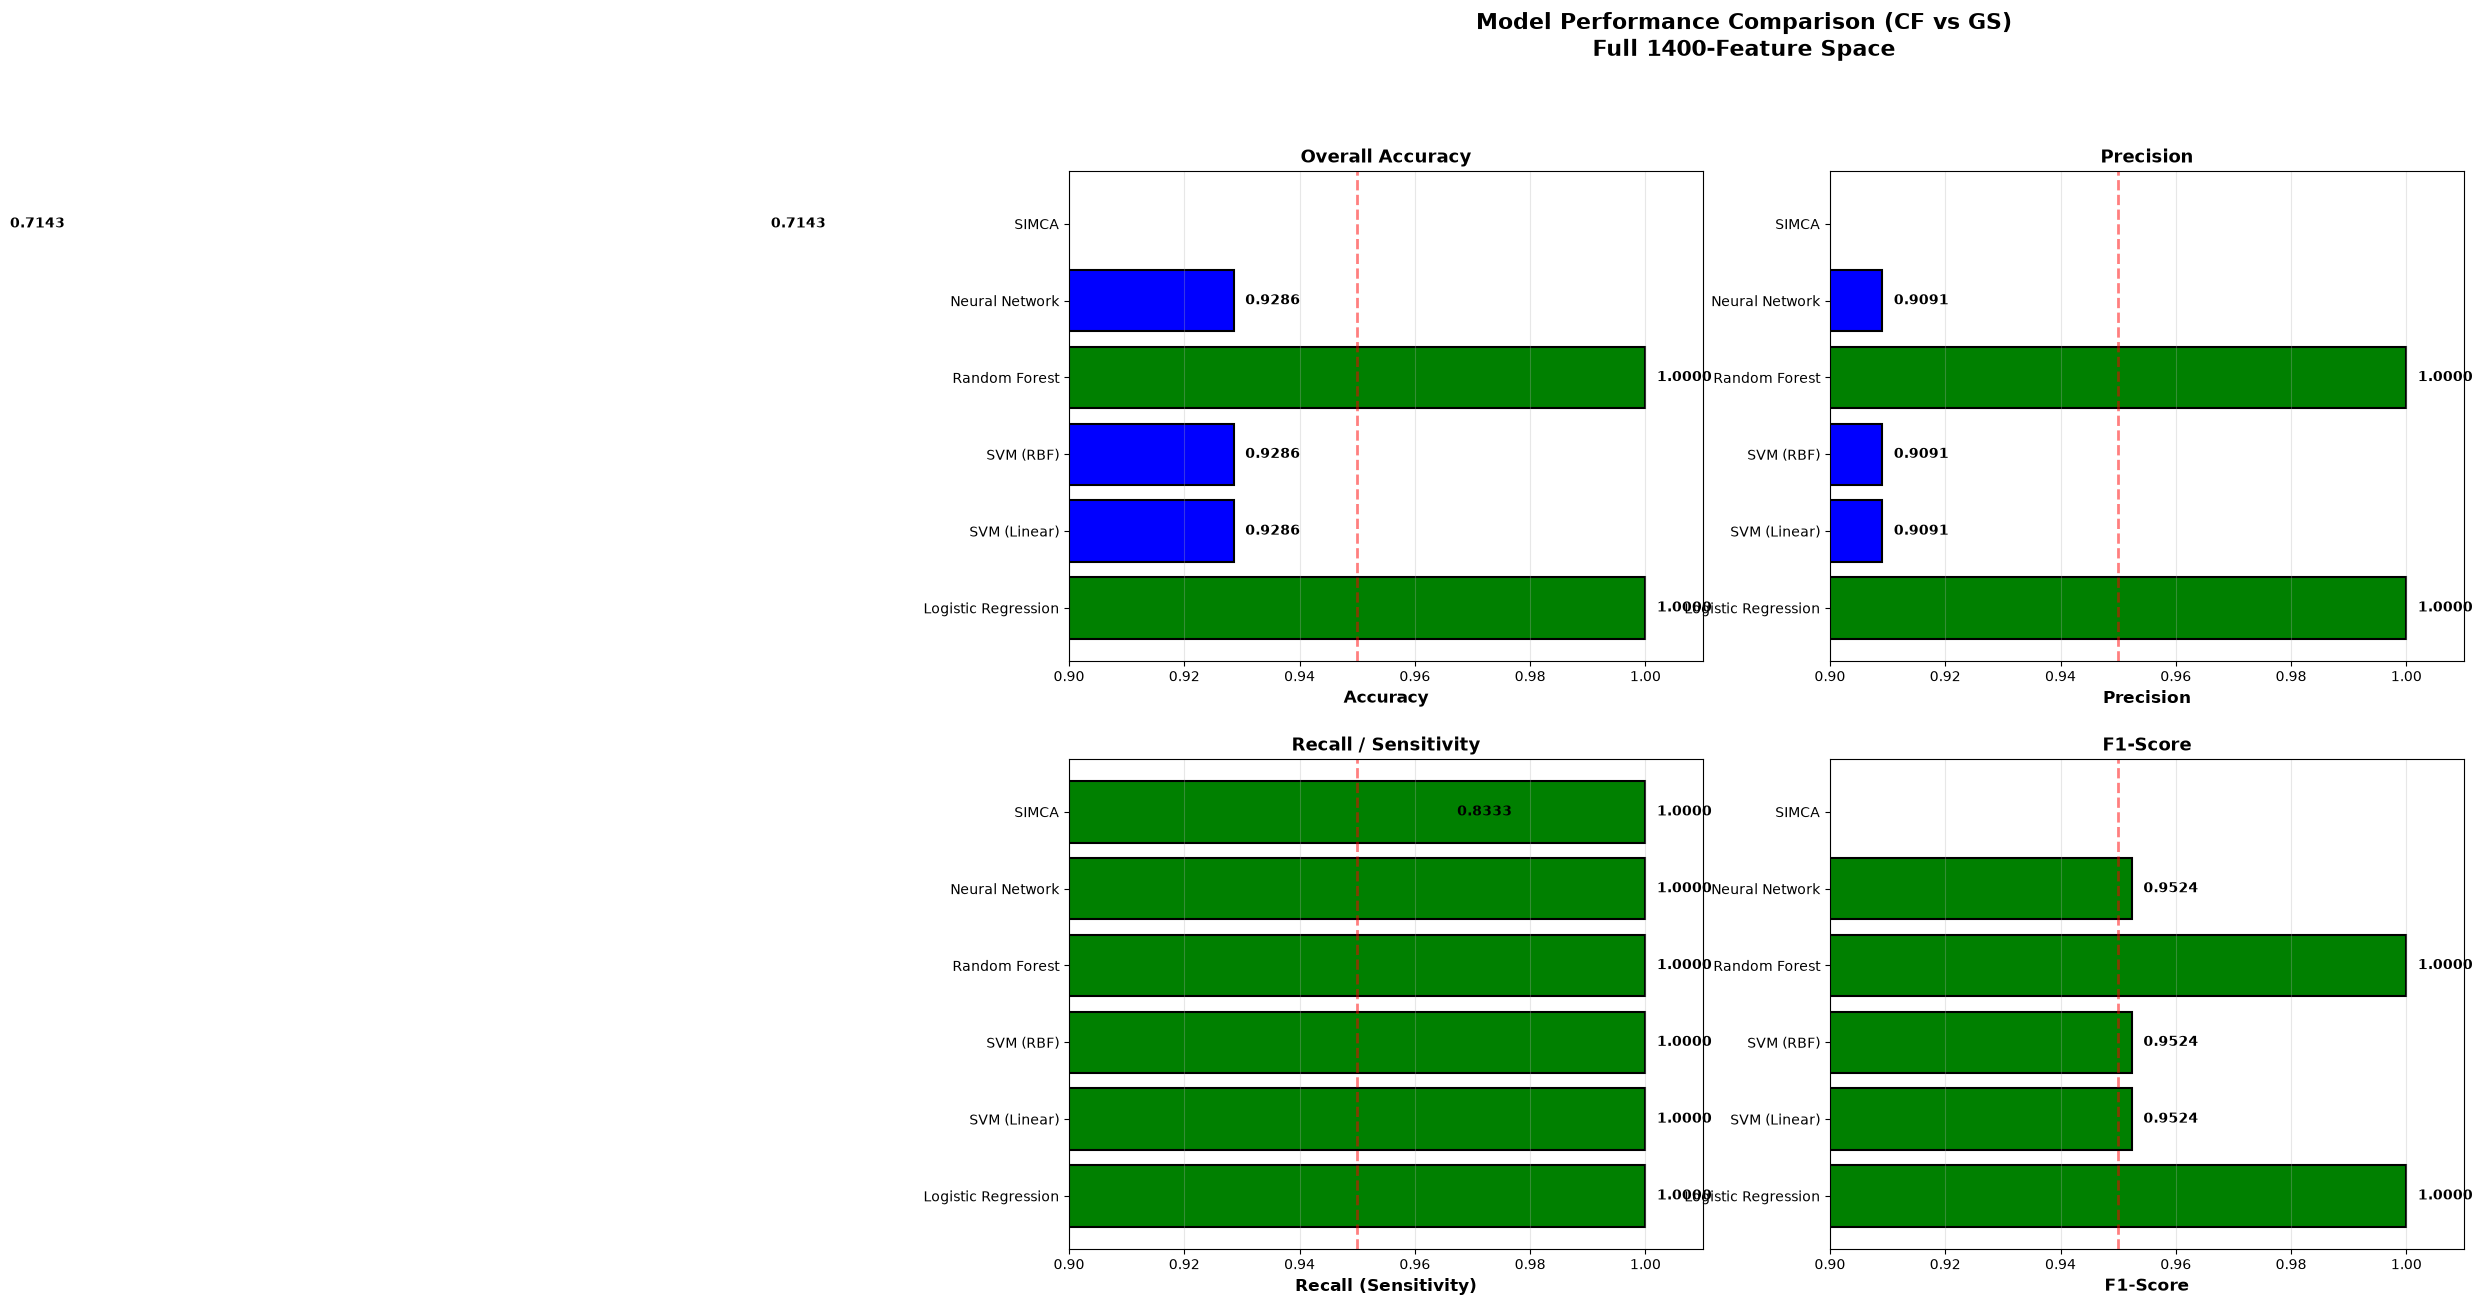

In [123]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Accuracy
ax = axes[0, 0]
models = metrics_df['Model']
accuracies = metrics_df['Accuracy']
colors = ['green' if acc > 0.95 else 'blue' for acc in accuracies]

bars = ax.barh(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Overall Accuracy', fontsize=13, fontweight='bold')
ax.set_xlim([0.9, 1.01])
ax.axvline(x=0.95, color='red', linestyle='--', linewidth=2, alpha=0.5)

for i, (m, a) in enumerate(zip(models, accuracies)):
    ax.text(a + 0.002, i, f'{a:.4f}', va='center', fontsize=10, fontweight='bold')

ax.grid(axis='x', alpha=0.3)

# Precision
ax = axes[0, 1]
precisions = metrics_df['Precision']
colors = ['green' if p > 0.95 else 'blue' for p in precisions]

ax.barh(models, precisions, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision', fontsize=13, fontweight='bold')
ax.set_xlim([0.9, 1.01])
ax.axvline(x=0.95, color='red', linestyle='--', linewidth=2, alpha=0.5)

for i, (m, p) in enumerate(zip(models, precisions)):
    ax.text(p + 0.002, i, f'{p:.4f}', va='center', fontsize=10, fontweight='bold')

ax.grid(axis='x', alpha=0.3)

# Recall (Sensitivity)
ax = axes[1, 0]
recalls = metrics_df['Recall']
colors = ['green' if r > 0.95 else 'blue' for r in recalls]

ax.barh(models, recalls, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('Recall / Sensitivity', fontsize=13, fontweight='bold')
ax.set_xlim([0.9, 1.01])
ax.axvline(x=0.95, color='red', linestyle='--', linewidth=2, alpha=0.5)

for i, (m, r) in enumerate(zip(models, recalls)):
    ax.text(r + 0.002, i, f'{r:.4f}', va='center', fontsize=10, fontweight='bold')

ax.grid(axis='x', alpha=0.3)

# F1-Score
ax = axes[1, 1]
f1_scores = metrics_df['F1_Score']
colors = ['green' if f > 0.95 else 'blue' for f in f1_scores]

ax.barh(models, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('F1-Score', fontsize=13, fontweight='bold')
ax.set_xlim([0.9, 1.01])
ax.axvline(x=0.95, color='red', linestyle='--', linewidth=2, alpha=0.5)

for i, (m, f) in enumerate(zip(models, f1_scores)):
    ax.text(f + 0.002, i, f'{f:.4f}', va='center', fontsize=10, fontweight='bold')

ax.grid(axis='x', alpha=0.3)

plt.suptitle('Model Performance Comparison (CF vs GS)\nFull 1400-Feature Space',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

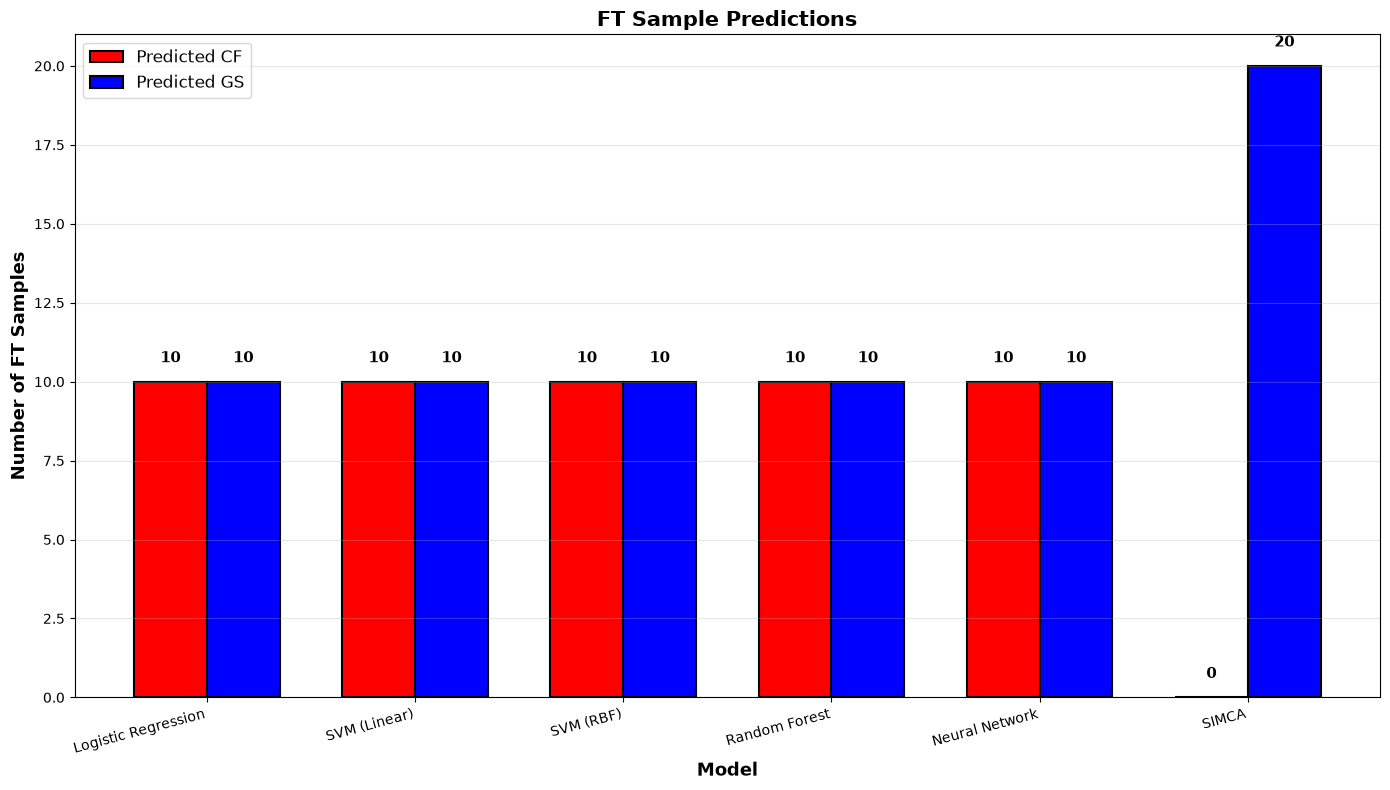

In [124]:
fig, ax = plt.subplots(figsize=(14, 8))

models_list = list(ft_predictions.keys())
x = np.arange(len(models_list))
width = 0.35

n_cf_list = [np.sum(ft_predictions[m] == 0) for m in models_list]
n_gs_list = [np.sum(ft_predictions[m] == 1) for m in models_list]

bars1 = ax.bar(x - width/2, n_cf_list, width, label='Predicted CF',
              color='red', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, n_gs_list, width, label='Predicted GS',
              color='blue', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of FT Samples', fontsize=13, fontweight='bold')
ax.set_title(f'FT Sample Predictions',
            fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (cf, gs) in enumerate(zip(n_cf_list, n_gs_list)):
    ax.text(i - width/2, cf + 0.5, str(cf), ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.text(i + width/2, gs + 0.5, str(gs), ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [125]:
# PCA for visualization
pca_viz = PCA(n_components=2)
X_train_pca = pca_viz.fit_transform(X_train_final)
X_test_pca = pca_viz.transform(X_test_final)
X_ft_pca = pca_viz.transform(X_ft)

# Train models on PCA for boundary
models_pca = {}

models_pca['Logistic Regression'] = LogisticRegression(random_state=42, max_iter=1000)
models_pca['Logistic Regression'].fit(X_train_pca, y_train_final)

models_pca['SVM (Linear)'] = SVC(kernel='linear', random_state=42)
models_pca['SVM (Linear)'].fit(X_train_pca, y_train_final)

models_pca['SVM (RBF)'] = SVC(kernel='rbf', random_state=42)
models_pca['SVM (RBF)'].fit(X_train_pca, y_train_final)

models_pca['Random Forest'] = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
models_pca['Random Forest'].fit(X_train_pca, y_train_final)

models_pca['Neural Network'] = MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=500, random_state=42, early_stopping=True)
models_pca['Neural Network'].fit(X_train_pca, y_train_final)

models_pca['SIMCA'] = SIMCAClassifier(n_components=2, alpha=0.05)
models_pca['SIMCA'].fit(X_train_pca, y_train_final)

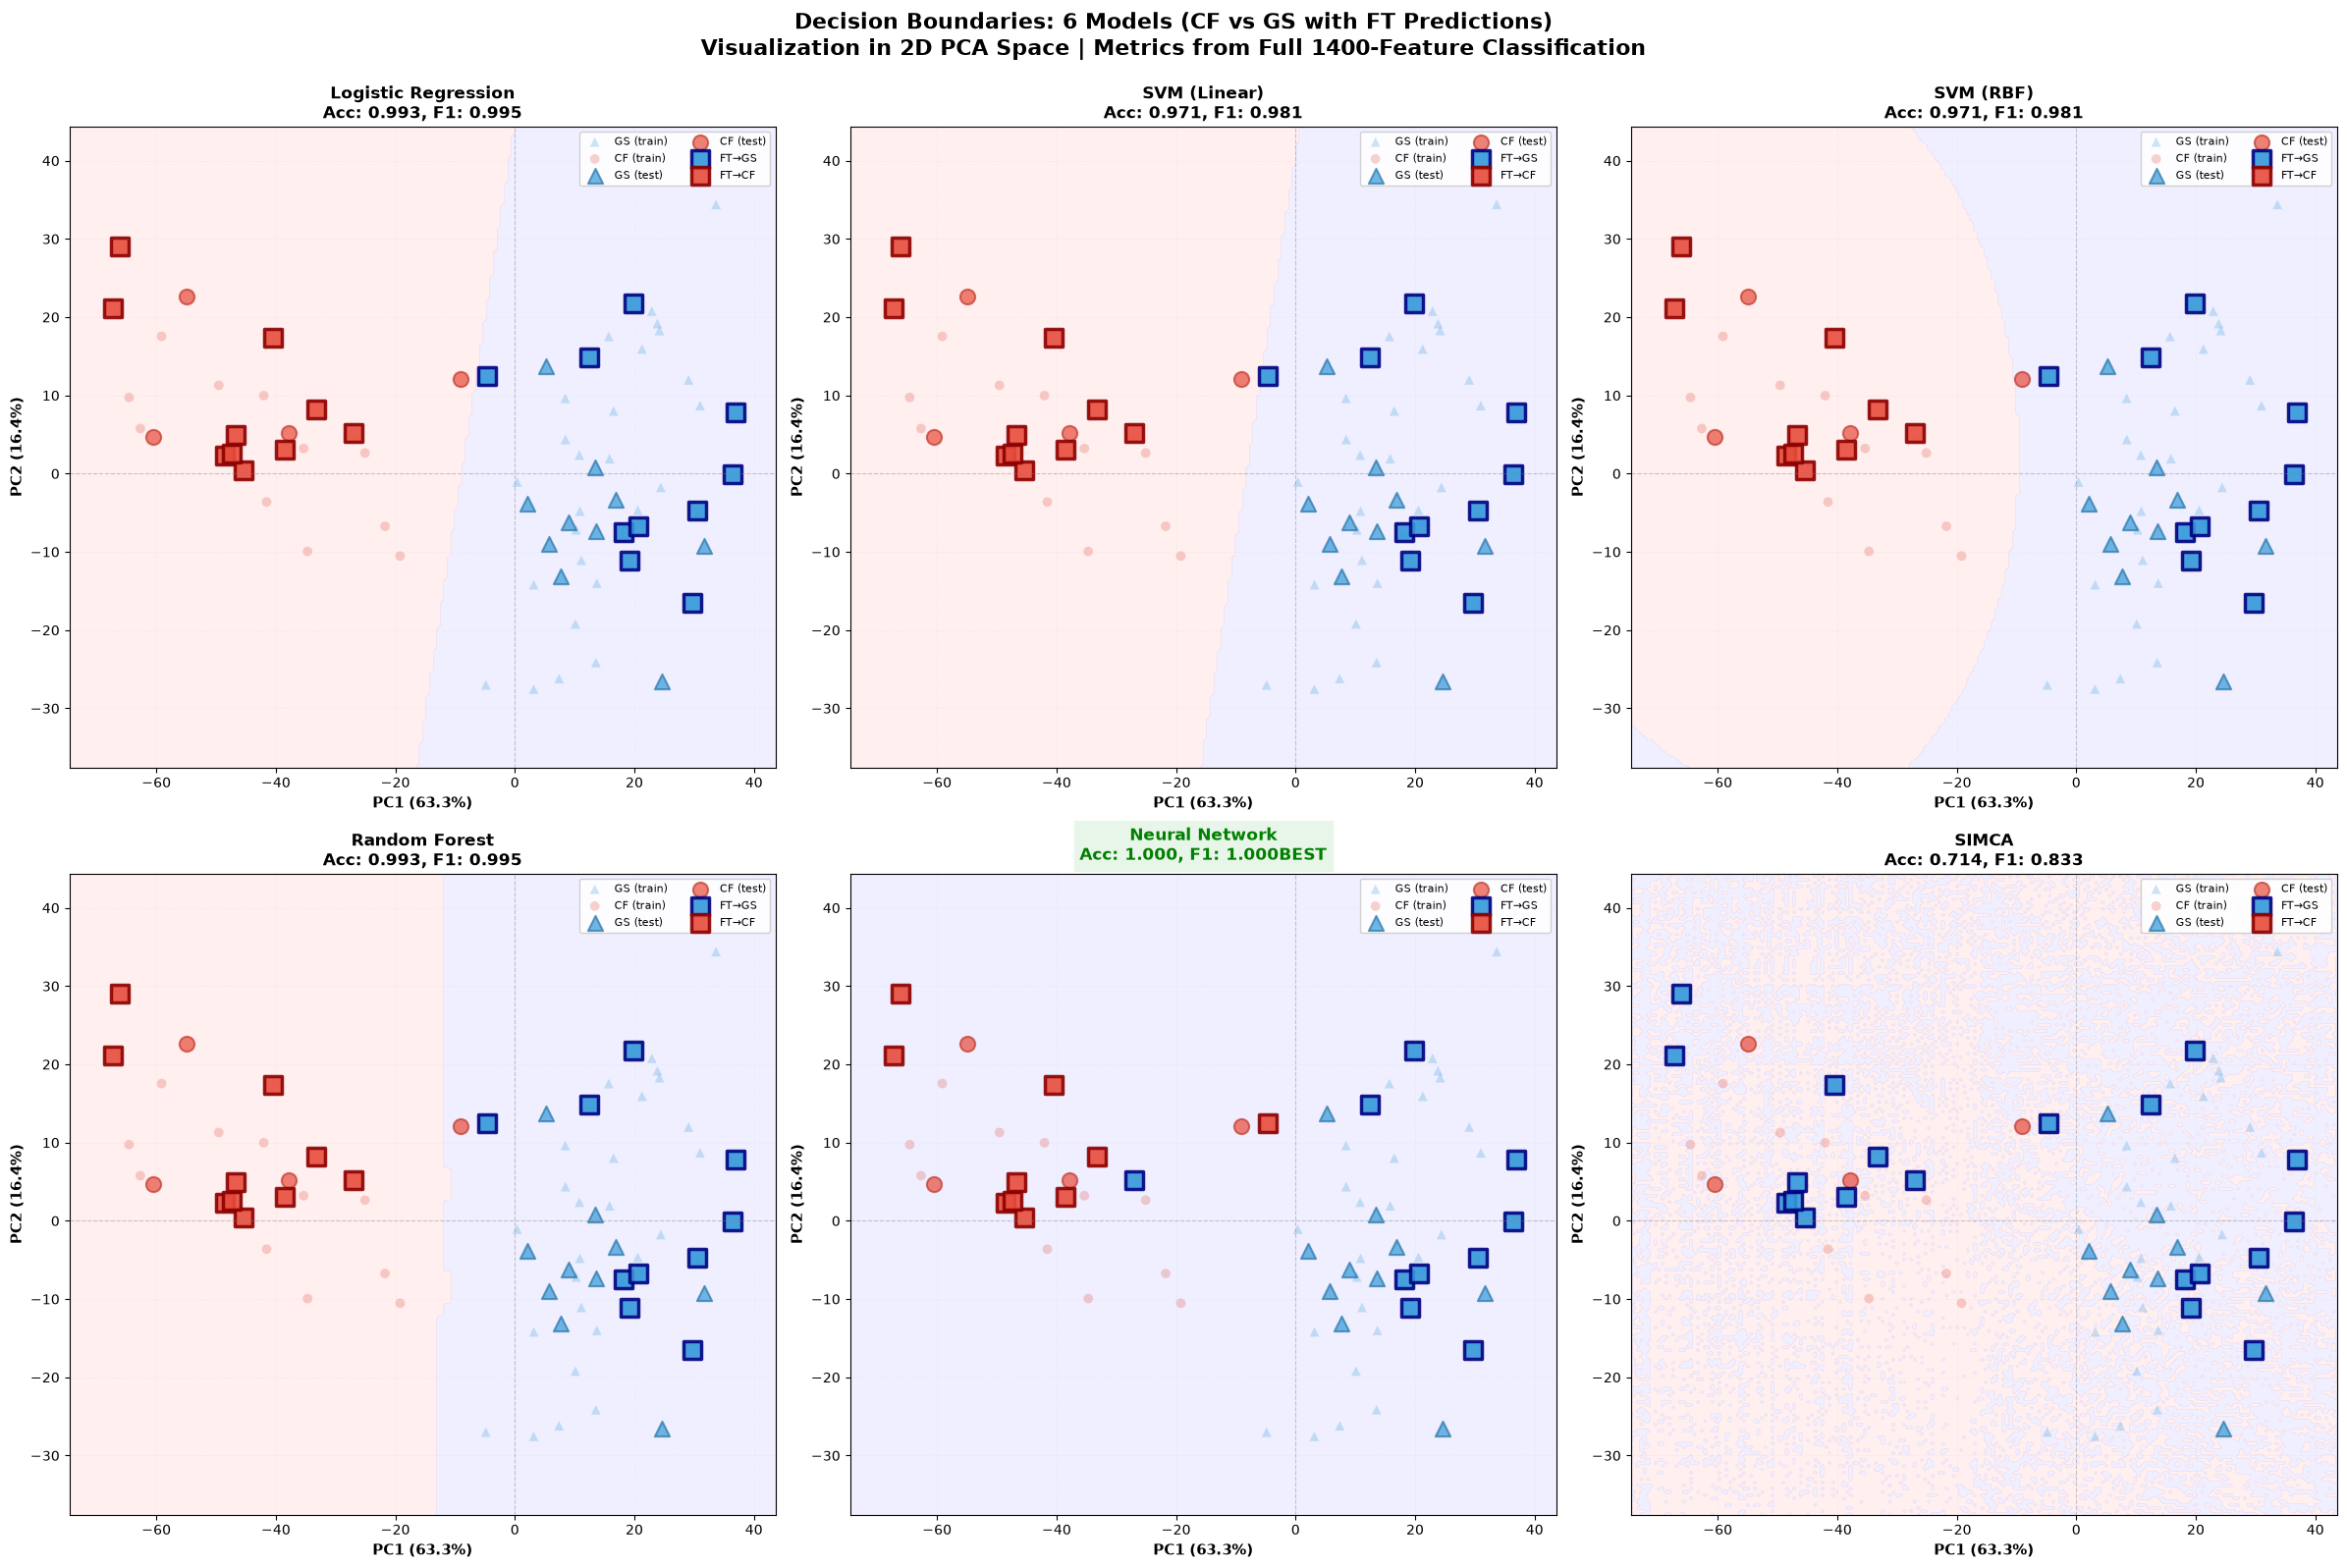

In [126]:
# Create plot
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
axes = axes.ravel()

x_min, x_max = X_train_pca[:, 0].min() - 10, X_train_pca[:, 0].max() + 10
y_min, y_max = X_train_pca[:, 1].min() - 10, X_train_pca[:, 1].max() + 10
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

model_order = ['Logistic Regression', 'SVM (Linear)', 'SVM (RBF)',
               'Random Forest', 'Neural Network', 'SIMCA']

best_f1 = max([averaged_results[m]['f1_mean'] for m in model_order])

for idx, model_name in enumerate(model_order):
    ax = axes[idx]
    model_pca = models_pca[model_name]

    # Decision boundary
    Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 0.5, 1], colors=['#ffcccc', '#ccccff'])

    # Training data (small, faded)
    train_gs = y_train_final == 1
    train_cf = y_train_final == 0
    ax.scatter(X_train_pca[train_gs, 0], X_train_pca[train_gs, 1],
              c='#3498db', marker='^', s=50, alpha=0.25, edgecolors='none', label='GS (train)')
    ax.scatter(X_train_pca[train_cf, 0], X_train_pca[train_cf, 1],
              c='#e74c3c', marker='o', s=50, alpha=0.25, edgecolors='none', label='CF (train)')

    # Test data (medium, bright)
    test_gs = y_test_final == 1
    test_cf = y_test_final == 0
    ax.scatter(X_test_pca[test_gs, 0], X_test_pca[test_gs, 1],
              c='#3498db', marker='^', s=120, alpha=0.7,
              edgecolors='#2874a6', linewidth=1.5, label='GS (test)')
    ax.scatter(X_test_pca[test_cf, 0], X_test_pca[test_cf, 1],
              c='#e74c3c', marker='o', s=120, alpha=0.7,
              edgecolors='#c0392b', linewidth=1.5, label='CF (test)')

    # FT predictions (large, very bright, squares)
    ft_pred = ft_predictions[model_name]
    ft_pred_gs = ft_pred == 1
    ft_pred_cf = ft_pred == 0

    ax.scatter(X_ft_pca[ft_pred_gs, 0], X_ft_pca[ft_pred_gs, 1],
              c='#3498db', marker='s', s=150, alpha=0.9,
              edgecolors='navy', linewidth=2.5, label='FT→GS')
    ax.scatter(X_ft_pca[ft_pred_cf, 0], X_ft_pca[ft_pred_cf, 1],
              c='#e74c3c', marker='s', s=150, alpha=0.9,
              edgecolors='darkred', linewidth=2.5, label='FT→CF')

    # Styling
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)

    ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)',
                  fontsize=11, fontweight='bold')
    ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)',
                  fontsize=11, fontweight='bold')

    # Metrics from full features
    acc_full = averaged_results[model_name]['accuracy_mean']
    f1_full = averaged_results[model_name]['f1_mean']
    is_best = (f1_full == best_f1)

    title_text = f'{model_name}\nAcc: {acc_full:.3f}, F1: {f1_full:.3f}'
    if is_best:
        title_text += 'BEST'
        ax.set_title(title_text, fontsize=12, fontweight='bold',
                    color='green', backgroundcolor='#e8f5e9', pad=10)
    else:
        ax.set_title(title_text, fontsize=12, fontweight='bold')

    ax.legend(fontsize=8, loc='best', framealpha=0.9, ncol=2)
    ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.5)

plt.suptitle('Decision Boundaries: 6 Models (CF vs GS with FT Predictions)\n' +
             'Visualization in 2D PCA Space | Metrics from Full 1400-Feature Classification',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# FT Prediction Agreement Analysis

In [127]:
ft_pred_df = pd.DataFrame(ft_predictions)
ft_pred_df.index.name = 'FT_Sample'

for model in ft_pred_df.columns:
    n_cf = (ft_pred_df[model] == 0).sum()
    n_gs = (ft_pred_df[model] == 1).sum()
    pct_gs = (n_gs / len(ft_pred_df)) * 100
    print(f"{model:<20} CF: {n_cf:2d} ({100-pct_gs:5.1f}%)  |  GS: {n_gs:2d} ({pct_gs:5.1f}%)")

Logistic Regression  CF: 10 ( 50.0%)  |  GS: 10 ( 50.0%)
SVM (Linear)         CF: 10 ( 50.0%)  |  GS: 10 ( 50.0%)
SVM (RBF)            CF: 10 ( 50.0%)  |  GS: 10 ( 50.0%)
Random Forest        CF: 10 ( 50.0%)  |  GS: 10 ( 50.0%)
Neural Network       CF: 10 ( 50.0%)  |  GS: 10 ( 50.0%)
SIMCA                CF:  0 (  0.0%)  |  GS: 20 (100.0%)


In [128]:
agreement_matrix = np.zeros((len(final_models), len(final_models)))
model_names = list(final_models.keys())

for i, model1 in enumerate(model_names):
    for j, model2 in enumerate(model_names):
        agreement = (ft_pred_df[model1] == ft_pred_df[model2]).sum()
        agreement_pct = (agreement / len(ft_pred_df)) * 100
        agreement_matrix[i, j] = agreement_pct

agreement_df = pd.DataFrame(agreement_matrix,
                            index=model_names,
                            columns=model_names)

In [129]:
avg_agreement = {}

for model in model_names:
    others_agreement = agreement_df[model].drop(model).values
    avg_agreement[model] = others_agreement.mean()

print("\nAverage Agreement with Other Models:")
for model, avg in sorted(avg_agreement.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<20} {avg:.1f}%")


Average Agreement with Other Models:
Logistic Regression  88.0%
SVM (Linear)         88.0%
SVM (RBF)            88.0%
Random Forest        88.0%
Neural Network       82.0%
SIMCA                50.0%


In [130]:
# For each FT sample, check how many models agree
prediction_variance = ft_pred_df.apply(lambda row: row.nunique(), axis=1)
disagreement_samples = prediction_variance[prediction_variance > 1].index

print(f"\nTotal FT samples with disagreement: {len(disagreement_samples)}/{len(ft_pred_df)}")


Total FT samples with disagreement: 11/20


In [131]:
if len(disagreement_samples) > 0:
    print("\nSamples where models disagree:")
    for idx in disagreement_samples[:10]:  # Show first 10
        predictions = ft_pred_df.loc[idx]
        n_cf = (predictions == 0).sum()
        n_gs = (predictions == 1).sum()
        print(f"Sample {idx}: {n_cf} models→CF, {n_gs} models→GS")

    if len(disagreement_samples) > 10:
        print(f"and {len(disagreement_samples) - 10} more")


Samples where models disagree:
Sample 0: 5 models→CF, 1 models→GS
Sample 1: 5 models→CF, 1 models→GS
Sample 2: 5 models→CF, 1 models→GS
Sample 3: 5 models→CF, 1 models→GS
Sample 6: 5 models→CF, 1 models→GS
Sample 8: 5 models→CF, 1 models→GS
Sample 9: 5 models→CF, 1 models→GS
Sample 10: 4 models→CF, 2 models→GS
Sample 11: 1 models→CF, 5 models→GS
Sample 12: 5 models→CF, 1 models→GS
and 1 more


In [132]:
ft_pred_df['Majority_Vote'] = ft_pred_df.apply(
    lambda row: 1 if row.sum() >= len(final_models)/2 else 0, axis=1
)

consensus_levels = ft_pred_df.iloc[:, :-1].apply(lambda row: row.value_counts().max(), axis=1)
print("\nConsensus Distribution:")
print(f"Unanimous (6/6 agree): {(consensus_levels == 6).sum()} samples")
print(f"Strong (5/6 agree):    {(consensus_levels == 5).sum()} samples")
print(f"Majority (4/6 agree):  {(consensus_levels == 4).sum()} samples")
print(f"Split (3/3):           {(consensus_levels == 3).sum()} samples")


Consensus Distribution:
Unanimous (6/6 agree): 9 samples
Strong (5/6 agree):    10 samples
Majority (4/6 agree):  1 samples
Split (3/3):           0 samples


<function matplotlib.pyplot.show(close=None, block=None)>

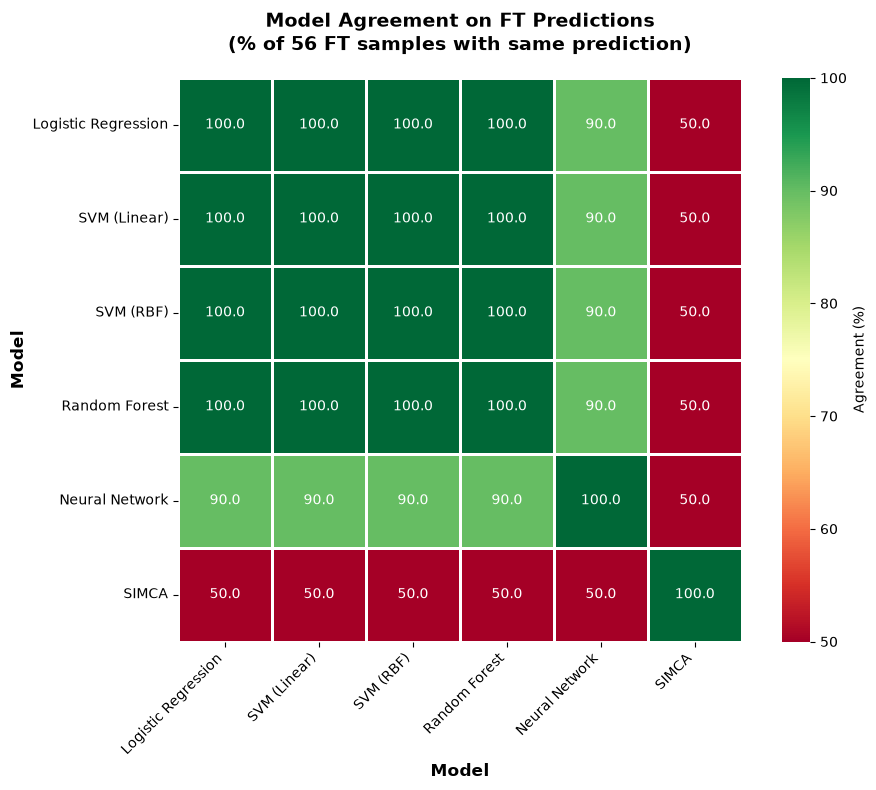

In [133]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(agreement_df, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=50, vmax=100, center=75,
            square=True, linewidths=1, cbar_kws={'label': 'Agreement (%)'},
            ax=ax)

ax.set_title('Model Agreement on FT Predictions\n(% of 56 FT samples with same prediction)',
            fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show

# Overtraining Detection

In [134]:
# Calculate train vs test performance for each model
overtraining_analysis = []

for name, model in final_models.items():
    # Training performance
    y_train_pred = model.predict(X_train_final)
    train_acc = accuracy_score(y_train_final, y_train_pred)

    # Test performance
    y_test_pred = model.predict(X_test_final)
    test_acc = accuracy_score(y_test_final, y_test_pred)

    # Cross-validation performance (from averaged_results)
    cv_acc_mean = averaged_results[name]['accuracy_mean']
    cv_acc_std = averaged_results[name]['accuracy_std']

    # Overtraining metrics
    train_test_gap = train_acc - test_acc
    train_cv_gap = train_acc - cv_acc_mean

    overtraining_analysis.append({
        'Model': name,
        'Train_Acc': train_acc,
        'Test_Acc': test_acc,
        'CV_Acc_Mean': cv_acc_mean,
        'CV_Acc_Std': cv_acc_std,
        'Train-Test_Gap': train_test_gap,
        'Train-CV_Gap': train_cv_gap
    })

overtraining_df = pd.DataFrame(overtraining_analysis)

overtraining_df

,Model,Train_Acc,Test_Acc,CV_Acc_Mean,CV_Acc_Std,Train-Test_Gap,Train-CV_Gap
0,Logistic Regression,1.000,1.000000,0.992857,0.021429,0.000000,0.007143
1,SVM (Linear),1.000,0.928571,0.971429,0.034993,0.071429,0.028571
2,SVM (RBF),1.000,0.928571,0.971429,0.034993,0.071429,0.028571
3,Random Forest,1.000,1.000000,0.992857,0.021429,0.000000,0.007143
4,Neural Network,0.975,0.928571,1.000000,0.000000,0.046429,-0.025000
5,SIMCA,1.000,0.714286,0.714286,0.000000,0.285714,0.285714


In [135]:
for _, row in overtraining_df.iterrows():
    model = row['Model']
    gap = row['Train-Test_Gap']
    cv_std = row['CV_Acc_Std']

    # Criteria for overtraining
    is_overtrained = False
    reasons = []

    if gap > 0.05:  # >5% gap
        is_overtrained = True
        reasons.append(f"Large train-test gap: {gap*100:.1f}%")

    if cv_std > 0.05:  # High variance in CV
        is_overtrained = True
        reasons.append(f"High CV variance: {cv_std*100:.1f}%")

    if row['Train_Acc'] == 1.0 and row['Test_Acc'] < 0.95:
        is_overtrained = True
        reasons.append("Perfect train, imperfect test")

    status = "OVERTRAINED" if is_overtrained else "GOOD"
    print(f"\n{model}:")
    print(f"Status: {status}")
    print(f"Train Acc: {row['Train_Acc']:.4f}")
    print(f"Test Acc:  {row['Test_Acc']:.4f}")
    print(f"CV Acc:    {row['CV_Acc_Mean']:.4f} ± {row['CV_Acc_Std']:.4f}")
    print(f"Gap:       {gap*100:.2f}%")

    if is_overtrained:
        for reason in reasons:
            print(f"    - {reason}")


Logistic Regression:
Status: GOOD
Train Acc: 1.0000
Test Acc:  1.0000
CV Acc:    0.9929 ± 0.0214
Gap:       0.00%

SVM (Linear):
Status: OVERTRAINED
Train Acc: 1.0000
Test Acc:  0.9286
CV Acc:    0.9714 ± 0.0350
Gap:       7.14%
    - Large train-test gap: 7.1%
    - Perfect train, imperfect test

SVM (RBF):
Status: OVERTRAINED
Train Acc: 1.0000
Test Acc:  0.9286
CV Acc:    0.9714 ± 0.0350
Gap:       7.14%
    - Large train-test gap: 7.1%
    - Perfect train, imperfect test

Random Forest:
Status: GOOD
Train Acc: 1.0000
Test Acc:  1.0000
CV Acc:    0.9929 ± 0.0214
Gap:       0.00%

Neural Network:
Status: GOOD
Train Acc: 0.9750
Test Acc:  0.9286
CV Acc:    1.0000 ± 0.0000
Gap:       4.64%

SIMCA:
Status: OVERTRAINED
Train Acc: 1.0000
Test Acc:  0.7143
CV Acc:    0.7143 ± 0.0000
Gap:       28.57%
    - Large train-test gap: 28.6%
    - Perfect train, imperfect test


<function matplotlib.pyplot.show(close=None, block=None)>

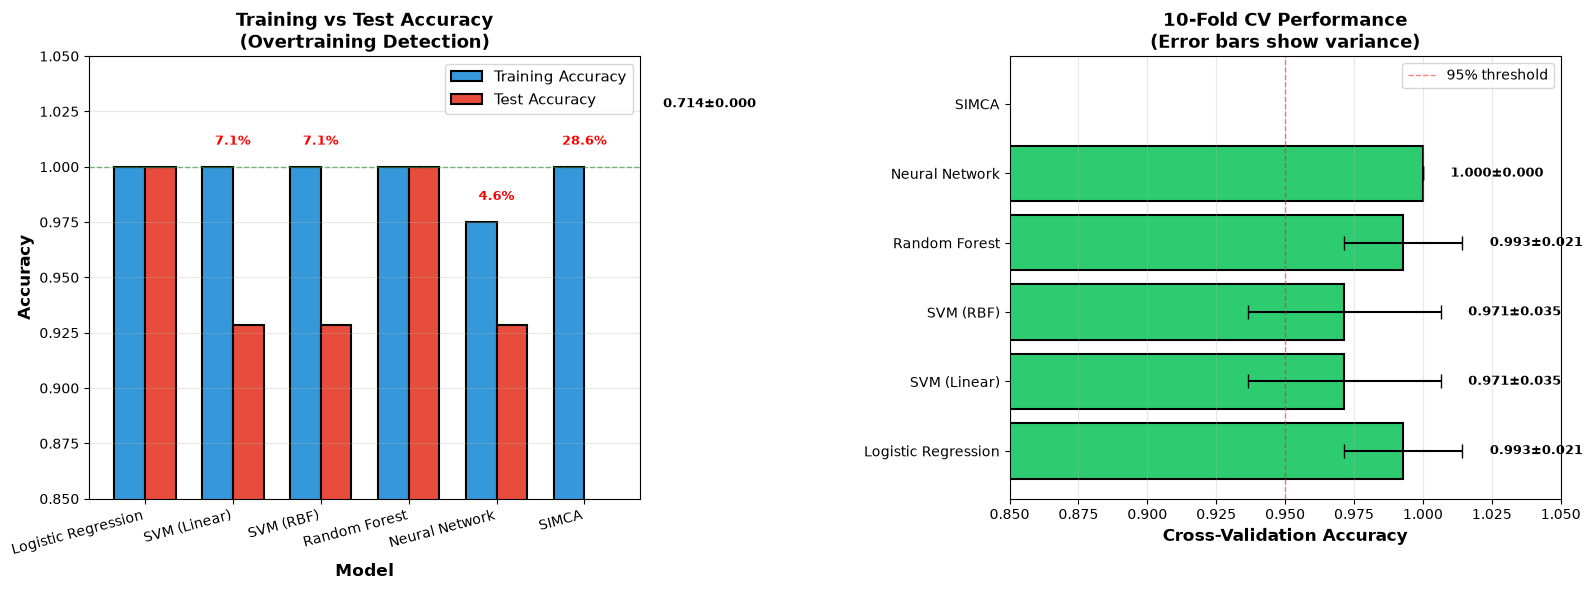

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Train vs Test Accuracy
ax = axes[0]
models = overtraining_df['Model']
x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, overtraining_df['Train_Acc'], width,
       label='Training Accuracy', color='#3498db', edgecolor='black', linewidth=1.5)
ax.bar(x + width/2, overtraining_df['Test_Acc'], width,
       label='Test Accuracy', color='#e74c3c', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Training vs Test Accuracy\n(Overtraining Detection)',
            fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([0.85, 1.05])
ax.axhline(y=1.0, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Perfect')
ax.grid(axis='y', alpha=0.3)

# Add gap annotations
for i, gap in enumerate(overtraining_df['Train-Test_Gap']):
    if abs(gap) > 0.01:
        ax.annotate(f'{gap*100:.1f}%',
                   xy=(i, max(overtraining_df.iloc[i]['Train_Acc'],
                             overtraining_df.iloc[i]['Test_Acc']) + 0.01),
                   ha='center', fontsize=9, color='red', fontweight='bold')

# Plot 2: Cross-Validation Variance
ax = axes[1]

ax.barh(models, overtraining_df['CV_Acc_Mean'],
        xerr=overtraining_df['CV_Acc_Std'],
        color='#2ecc71', edgecolor='black', linewidth=1.5, capsize=5)

ax.set_xlabel('Cross-Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('10-Fold CV Performance\n(Error bars show variance)',
            fontsize=13, fontweight='bold')
ax.set_xlim([0.85, 1.05])
ax.axvline(x=0.95, color='red', linestyle='--', linewidth=1, alpha=0.5, label='95% threshold')
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=10)

# Add value labels
for i, (mean, std) in enumerate(zip(overtraining_df['CV_Acc_Mean'],
                                    overtraining_df['CV_Acc_Std'])):
    ax.text(mean + std + 0.01, i, f'{mean:.3f}±{std:.3f}',
           va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show

# SVM (RBF) vs Random Forest Comparison

Note: In the results with original data input from the industry, these two performed similarly, so I made this part purely for the comparison and understanding the differences. These two classifications are not that similar in the case of the data I made up for the output display reasons. I did not use the real data for the confidentiality reasons (as required by the technology SME I worked with).

In [137]:
best_models = {
    'SVM (RBF)': final_models['SVM (RBF)'],
    'Random Forest': final_models['Random Forest']
}

In [138]:
# Get predictions
svm_test_pred = test_predictions['SVM (RBF)']
rf_test_pred = test_predictions['Random Forest']

svm_ft_pred = ft_predictions['SVM (RBF)']
rf_ft_pred = ft_predictions['Random Forest']

In [139]:
for name in best_models.keys():
    pred = test_predictions[name]
    acc = accuracy_score(y_test_final, pred)
    cm = confusion_matrix(y_test_final, pred)

In [140]:
comparison_metrics = []

In [141]:
for name in best_models.keys():
    pred = test_predictions[name]
    cm = confusion_matrix(y_test_final, pred)

    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test_final, pred),
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'Recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'F1_Score': averaged_results[name]['f1_mean'],
        'CV_Mean': averaged_results[name]['accuracy_mean'],
        'CV_Std': averaged_results[name]['accuracy_std']
    }

    comparison_metrics.append(metrics)

comparison_df = pd.DataFrame(comparison_metrics)
comparison_df

,Model,Accuracy,Precision,Recall,Specificity,F1_Score,CV_Mean,CV_Std
0,SVM (RBF),0.928571,0.909091,1.0,0.75,0.980952,0.971429,0.034993
1,Random Forest,1.000000,1.000000,1.0,1.00,0.995238,0.992857,0.021429


In [142]:
# Compare FT predictions between the two models
ft_agreement = (svm_ft_pred == rf_ft_pred).sum()
ft_disagreement = len(svm_ft_pred) - ft_agreement

print(f"\nAgreement on FT samples:")
print(f"Agree:    {ft_agreement}/{len(svm_ft_pred)} ({ft_agreement/len(svm_ft_pred)*100:.1f}%)")
print(f"Disagree: {ft_disagreement}/{len(svm_ft_pred)} ({ft_disagreement/len(svm_ft_pred)*100:.1f}%)")


Agreement on FT samples:
Agree:    20/20 (100.0%)
Disagree: 0/20 (0.0%)


In [143]:
svm_cf = (svm_ft_pred == 0).sum()
svm_gs = (svm_ft_pred == 1).sum()
rf_cf = (rf_ft_pred == 0).sum()
rf_gs = (rf_ft_pred == 1).sum()

print(f"\nSVM (RBF):     {svm_cf} → CF, {svm_gs} → GS")
print(f"Random Forest: {rf_cf} → CF, {rf_gs} → GS")


SVM (RBF):     10 → CF, 10 → GS
Random Forest: 10 → CF, 10 → GS


In [144]:
if ft_disagreement > 0:
    print(f"\nSamples where models disagree:")
    for i in range(len(svm_ft_pred)):
        if svm_ft_pred[i] != rf_ft_pred[i]:
            svm_label = 'GS' if svm_ft_pred[i] == 1 else 'CF'
            rf_label = 'GS' if rf_ft_pred[i] == 1 else 'CF'
            print(f"FT Sample {i}: SVM→{svm_label}, RF→{rf_label}")


<function matplotlib.pyplot.show(close=None, block=None)>

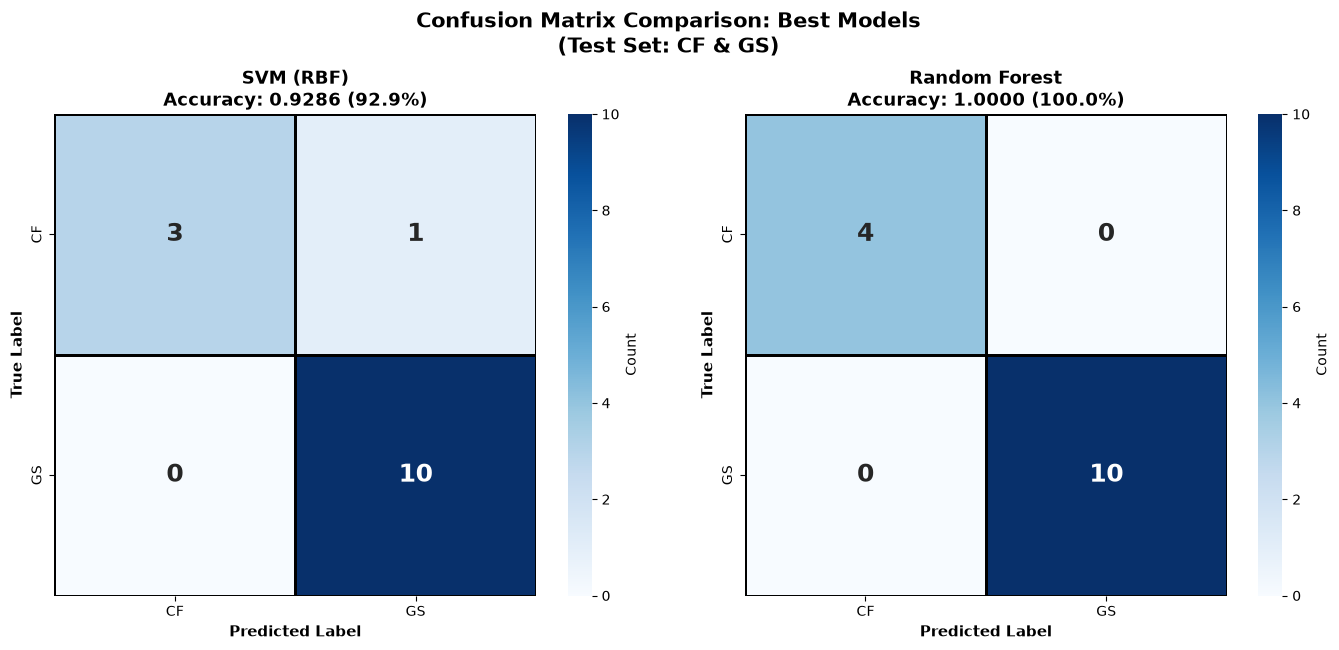

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (name, pred) in enumerate([('SVM (RBF)', svm_test_pred),
                                     ('Random Forest', rf_test_pred)]):
    ax = axes[idx]

    cm = confusion_matrix(y_test_final, pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['CF', 'GS'], yticklabels=['CF', 'GS'],
               ax=ax, cbar=True, square=True, linewidths=2, linecolor='black',
               annot_kws={'size': 18, 'weight': 'bold'},
               cbar_kws={'label': 'Count'})

    acc = accuracy_score(y_test_final, pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.4f} ({acc*100:.1f}%)',
                fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison: Best Models\n(Test Set: CF & GS)',
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

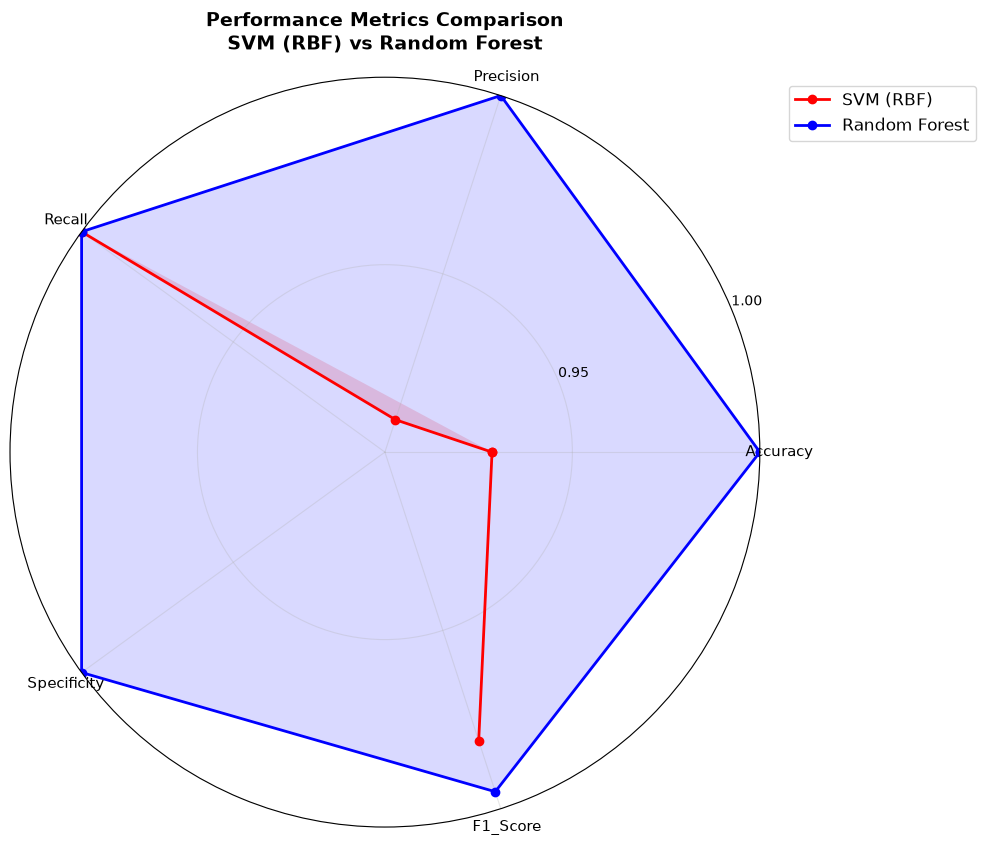

In [146]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1_Score']
angles = np.linspace(0, 2 * np.pi, len(metrics_to_plot), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

for i, row in comparison_df.iterrows():
    values = [row[m] for m in metrics_to_plot]
    values += values[:1]  # Complete the circle

    color = 'red' if row['Model'] == 'SVM (RBF)' else 'blue'
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0.9, 1.0)
ax.set_yticks([0.90, 0.95, 1.00])
ax.set_yticklabels(['0.90', '0.95', '1.00'])
ax.grid(True, alpha=0.3)
ax.set_title('Performance Metrics Comparison\nSVM (RBF) vs Random Forest',
            fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=12)

plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

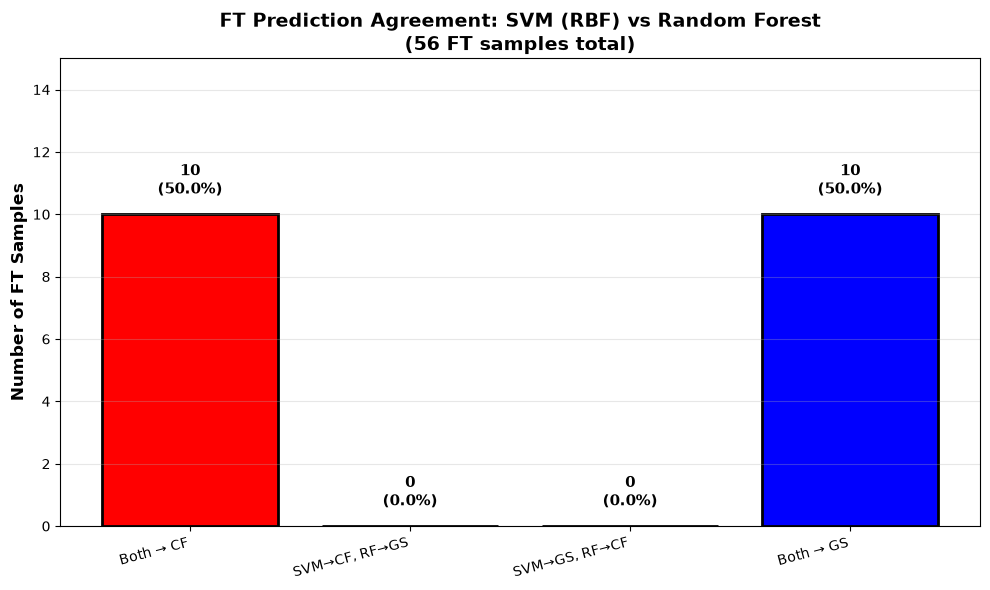

In [147]:
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Both → CF', 'SVM→CF, RF→GS', 'SVM→GS, RF→CF', 'Both → GS']
counts = [
    ((svm_ft_pred == 0) & (rf_ft_pred == 0)).sum(),
    ((svm_ft_pred == 0) & (rf_ft_pred == 1)).sum(),
    ((svm_ft_pred == 1) & (rf_ft_pred == 0)).sum(),
    ((svm_ft_pred == 1) & (rf_ft_pred == 1)).sum()
]

colors = ['red', 'yellow', 'yellow', 'blue']
bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=2)

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
           f'{count}\n({count/len(svm_ft_pred)*100:.1f}%)',
           ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of FT Samples', fontsize=12, fontweight='bold')
ax.set_title('FT Prediction Agreement: SVM (RBF) vs Random Forest\n(56 FT samples total)',
            fontsize=14, fontweight='bold')
ax.set_ylim([0, max(counts) + 5])
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show

In [148]:
print(X_clean_full.shape)

(74, 1400)
